In [18]:
import pandas as pd
df = pd.read_csv('/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v7_conflict_gold/run_v7_conflict_gold/test_dist.csv')
print(df.head())

       t  y_true  c_true  y0_prob  y1_prob  uplift_pred  pi_01_prior
0 1.0000  0.0000  0.0000   0.0014   0.0024       0.0009       0.0006
1 1.0000  0.0000  0.0000   0.0002   0.0003       0.0001       0.0004
2 0.0000  0.0000  0.0000   0.0014   0.0023       0.0009       0.0005
3 1.0000  0.0000  0.0000   0.0006   0.0011       0.0005       0.0246
4 1.0000  0.0000  0.0000   0.0002   0.0003       0.0001       0.0000


🔍 找到了 38 个测试集预测文件，开始执行排行榜分析...

🏆 全局 AUUC 排位赛及 5-10% 痛点修复情况 🏆
            Version   AUUC  AUUC (Rel V1%)  Lift@5  Lift@5 (Rel V1%)  Bucket_5_10  Bucket_5_10 (Rel V1%)
        y_v8_s1_t10 0.9147          3.4842  0.0133           24.3293       0.0028               -46.9690
     y_v7_soft_top5 0.9133          3.3180  0.0127           18.7839       0.0039               -25.5723
 y_v7_conflict_gold 0.9119          3.1624  0.0129           20.6241       0.0036               -31.7707
            y_v8_s4 0.9113          3.0929  0.0123           14.7010       0.0039               -26.6949
         y_v8_s3_t5 0.9102          2.9772  0.0119           11.1597       0.0026               -50.2687
y_v10_conflict_both 0.9099          2.9426  0.0135           25.9281       0.0029               -45.5045
    y_v7_hard_top10 0.9099          2.9326  0.0126           17.9034       0.0028               -46.6828
        y_v8_s3_t50 0.9098          2.9253  0.0130           20.8025       0.0030               -4

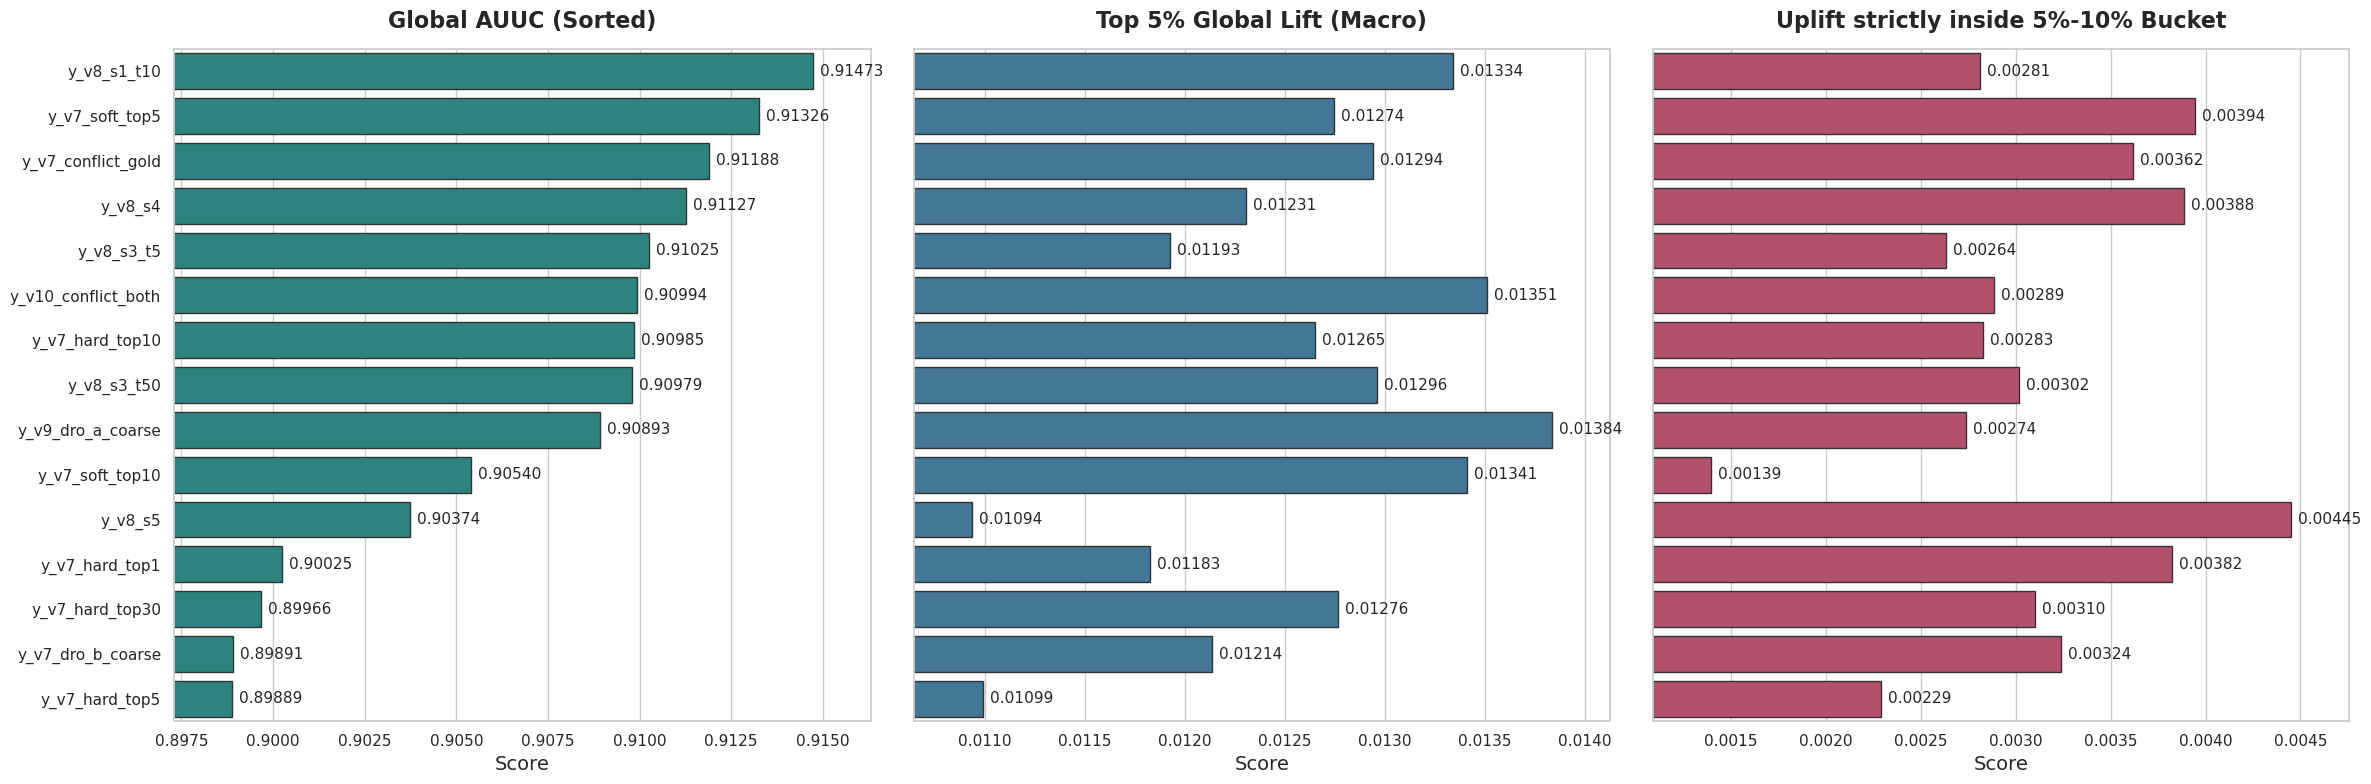

In [19]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 核心算子定义 (融合你的绝对归一化算法)
# ==========================================
def calculate_comprehensive_metrics(y_true, uplift_pred, t):
    """
    计算全局指标 (AUUC, Lift@K) 以及 局部桶指标 (Bucket ATE)
    """
    y_true, uplift_pred, t = np.array(y_true), np.array(uplift_pred), np.array(t)
    if len(y_true) == 0: return {}

    # 1. 按预测分数降序排列
    order = np.argsort(uplift_pred)[::-1]
    y_true_sorted = y_true[order]
    t_sorted = t[order]

    # ---------------------------------------------------------
    # [全局指标] AUUC & AUQC 计算
    # ---------------------------------------------------------
    n_t_cum = np.cumsum(t_sorted == 1)
    n_c_cum = np.cumsum(t_sorted == 0)
    y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
    y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

    n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
    n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)
    x_axis = np.arange(1, len(y_true) + 1) / len(y_true)

    # AUUC
    with np.errstate(invalid='ignore', divide='ignore'):
        uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
    uplift_curve = np.nan_to_num(uplift_curve)
    if abs(uplift_curve[-1]) > 1e-10:
        uplift_curve = uplift_curve / uplift_curve[-1]
    auuc = np.trapz(uplift_curve, x=x_axis)

    # AUQC
    with np.errstate(invalid='ignore', divide='ignore'):
        qini_curve = y_t_cum - (y_c_cum * n_t_safe / n_c_safe)
    qini_curve = np.nan_to_num(qini_curve)
    if abs(qini_curve[-1]) > 1e-10:
        qini_curve = qini_curve / qini_curve[-1]
    auqc = np.trapz(qini_curve, x=x_axis)

    # ---------------------------------------------------------
    # [全局指标] 累积 Lift@K
    # ---------------------------------------------------------
    def get_lift_at_k(k_pct):
        idx = int(len(y_true) * k_pct / 100.0)
        if idx == 0: return 0.0
        cr_t = np.sum(y_true_sorted[:idx] * (t_sorted[:idx] == 1)) / (np.sum(t_sorted[:idx] == 1) + 1e-6)
        cr_c = np.sum(y_true_sorted[:idx] * (t_sorted[:idx] == 0)) / (np.sum(t_sorted[:idx] == 0) + 1e-6)
        return cr_t - cr_c

    # ---------------------------------------------------------
    # [细化指标] 分桶 ATE (方法 A: 评估各自选出来的桶的含金量)
    # ---------------------------------------------------------
    def get_bucket_ate(start_pct, end_pct):
        start_idx = int(len(y_true) * start_pct / 100.0)
        end_idx = int(len(y_true) * end_pct / 100.0)
        
        y_slice = y_true_sorted[start_idx:end_idx]
        t_slice = t_sorted[start_idx:end_idx]
        
        if len(y_slice) == 0: return 0.0
        cr_t = np.sum(y_slice[t_slice == 1]) / (np.sum(t_slice == 1) + 1e-6)
        cr_c = np.sum(y_slice[t_slice == 0]) / (np.sum(t_slice == 0) + 1e-6)
        return cr_t - cr_c

    return {
        "AUUC": float(auuc),
        "Lift@5": float(get_lift_at_k(5)),
        "Lift@10": float(get_lift_at_k(10)),
        "Lift@20": float(get_lift_at_k(20)),
        "Lift@50": float(get_lift_at_k(50)),
        "Bucket_0_5": float(get_bucket_ate(0, 5)),
        "Bucket_5_10": float(get_bucket_ate(5, 10)),
        "Bucket_10_20": float(get_bucket_ate(10, 20)),
        "Bucket_20_50": float(get_bucket_ate(20, 50)),
        "Bucket_50_100": float(get_bucket_ate(50, 100))
    }

# ==========================================
# 2. 扫描数据并进行全局测评
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
BASELINE_VERSION = "y_v1_base"

csv_files = glob.glob(os.path.join(BASE_DIR, "**", "test_dist.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError("没有找到任何 test_dist.csv，请检查路径。")

print(f"🔍 找到了 {len(csv_files)} 个测试集预测文件，开始执行排行榜分析...")

results = []
baseline_metrics = None

for file in csv_files:
    # 提取版本名称 (例如 y_v7_conflict_gold)
    version_name = file.split("TARNET/")[1].split("/")[0]
    
    try:
        df = pd.read_csv(file)
        # 提取数组计算
        metrics = calculate_comprehensive_metrics(
            y_true=df['y_true'].values, 
            uplift_pred=df['uplift_pred'].values, 
            t=df['t'].values
        )
        metrics["Version"] = version_name
        results.append(metrics)
        
        if version_name == BASELINE_VERSION:
            baseline_metrics = metrics
            
    except Exception as e:
        print(f"❌ 读取 {version_name} 失败: {e}")

df_res = pd.DataFrame(results)

# ==========================================
# 3. 计算相对 V1 的 Relative Improvement
# ==========================================
def calc_relative(val, base_val):
    # 避免除以 0 或负数带来的诡异比例
    return (val - base_val) / (abs(base_val) + 1e-6) * 100.0

if baseline_metrics is not None:
    # 需要算 relative 的列
    cols_to_compare = [
        "AUUC", "Lift@5", "Lift@10", "Lift@20", "Lift@50",
        "Bucket_0_5", "Bucket_5_10", "Bucket_10_20", "Bucket_20_50", "Bucket_50_100"
    ]
    for col in cols_to_compare:
        base_val = baseline_metrics[col]
        df_res[f"{col} (Rel V1%)"] = df_res[col].apply(lambda x: calc_relative(x, base_val))

# ==========================================
# 4. 排序与落盘
# ==========================================
# 🌟 全局排位赛：必须按你的归一化 AUUC 从高到低排
df_res = df_res.sort_values(by="AUUC", ascending=False).reset_index(drop=True)

# 打印极度清爽的控制台表格
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.4f}'.format)

# 挑选出最核心的几列打印在终端，方便一眼看
print("\n🏆 全局 AUUC 排位赛及 5-10% 痛点修复情况 🏆")
print("=" * 140)
display_cols = ["Version", "AUUC", "AUUC (Rel V1%)", "Lift@5", "Lift@5 (Rel V1%)", 
                "Bucket_5_10", "Bucket_5_10 (Rel V1%)"]
print(df_res[display_cols].to_string(index=False))
print("=" * 140)

# 全量数据存 CSV
output_csv = "comprehensive_leaderboard.csv"
df_res.to_csv(output_csv, index=False)
print(f"✅ 全量数据 (包含 10-20, 20-50, 50-100等细化分桶) 已存至: {output_csv}")

# ==========================================
# 5. 论文级可视化画图
# ==========================================
print("🎨 正在生成核心指标对比图...")

# 取 Top 15 名画图（不然图太长塞不下）
plot_df = df_res.head(15)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# 封装一个辅助画图函数
def plot_metric(ax, data, x_col, color, title):
    sns.barplot(x=x_col, y="Version", data=data, ax=ax, color=color, edgecolor=".2")
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Score", fontsize=14)
    ax.set_ylabel("")
    
    # 动态微调 X 轴以放大差异
    min_val, max_val = data[x_col].min(), data[x_col].max()
    margin = (max_val - min_val) * 0.1
    ax.set_xlim(min_val - margin, max_val + margin)
    
    # 打上数值标签
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.5f}', (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)

# 第一张：全局大考能力
plot_metric(axes[0], plot_df, "AUUC", sns.color_palette("viridis", 1)[0], "Global AUUC (Sorted)")

# 第二张：头部捞金能力
plot_metric(axes[1], plot_df, "Lift@5", sns.color_palette("mako", 1)[0], "Top 5% Global Lift (Macro)")

# 第三张：5-10% 痛点排除能力 (看看 V1 的包厢里进了多少羊毛党，V7 踢出了多少)
plot_metric(axes[2], plot_df, "Bucket_5_10", sns.color_palette("flare", 1)[0], "Uplift strictly inside 5%-10% Bucket")

plt.tight_layout()
output_png = "comprehensive_leaderboard.png"
plt.savefig(output_png, dpi=300, bbox_inches='tight')
print(f"✅ 可视化图表已生成: {output_png}")


📈 补充表格：大盘渗透率下探 (Lift@10, Lift@20, Lift@50) 及相对 V1 提升
            Version  Lift@10  Lift@10 (Rel V1%)  Lift@20  Lift@20 (Rel V1%)  Lift@50  Lift@50 (Rel V1%)
        y_v8_s1_t10   0.0089             3.0439   0.0050             1.4247   0.0023             5.5951
     y_v7_soft_top5   0.0088             1.6489   0.0051             3.9604   0.0023             4.3083
 y_v7_conflict_gold   0.0090             3.9644   0.0050             1.0861   0.0023             5.7837
            y_v8_s4   0.0088             1.9142   0.0050             0.9230   0.0023             5.4059
         y_v8_s3_t5   0.0084            -2.5983   0.0051             3.4638   0.0022             3.2178
y_v10_conflict_both   0.0089             3.7770   0.0051             4.2783   0.0022             3.3684
    y_v7_hard_top10   0.0086            -0.0662   0.0051             3.0522   0.0022             3.1205
        y_v8_s3_t50   0.0087             1.2809   0.0050             1.7219   0.0022             4.0367
  y_v9_dro

✅ 补充可视化图表已生成: extended_lifts_leaderboard.png
🎉 所有评估流水线彻底执行完毕！


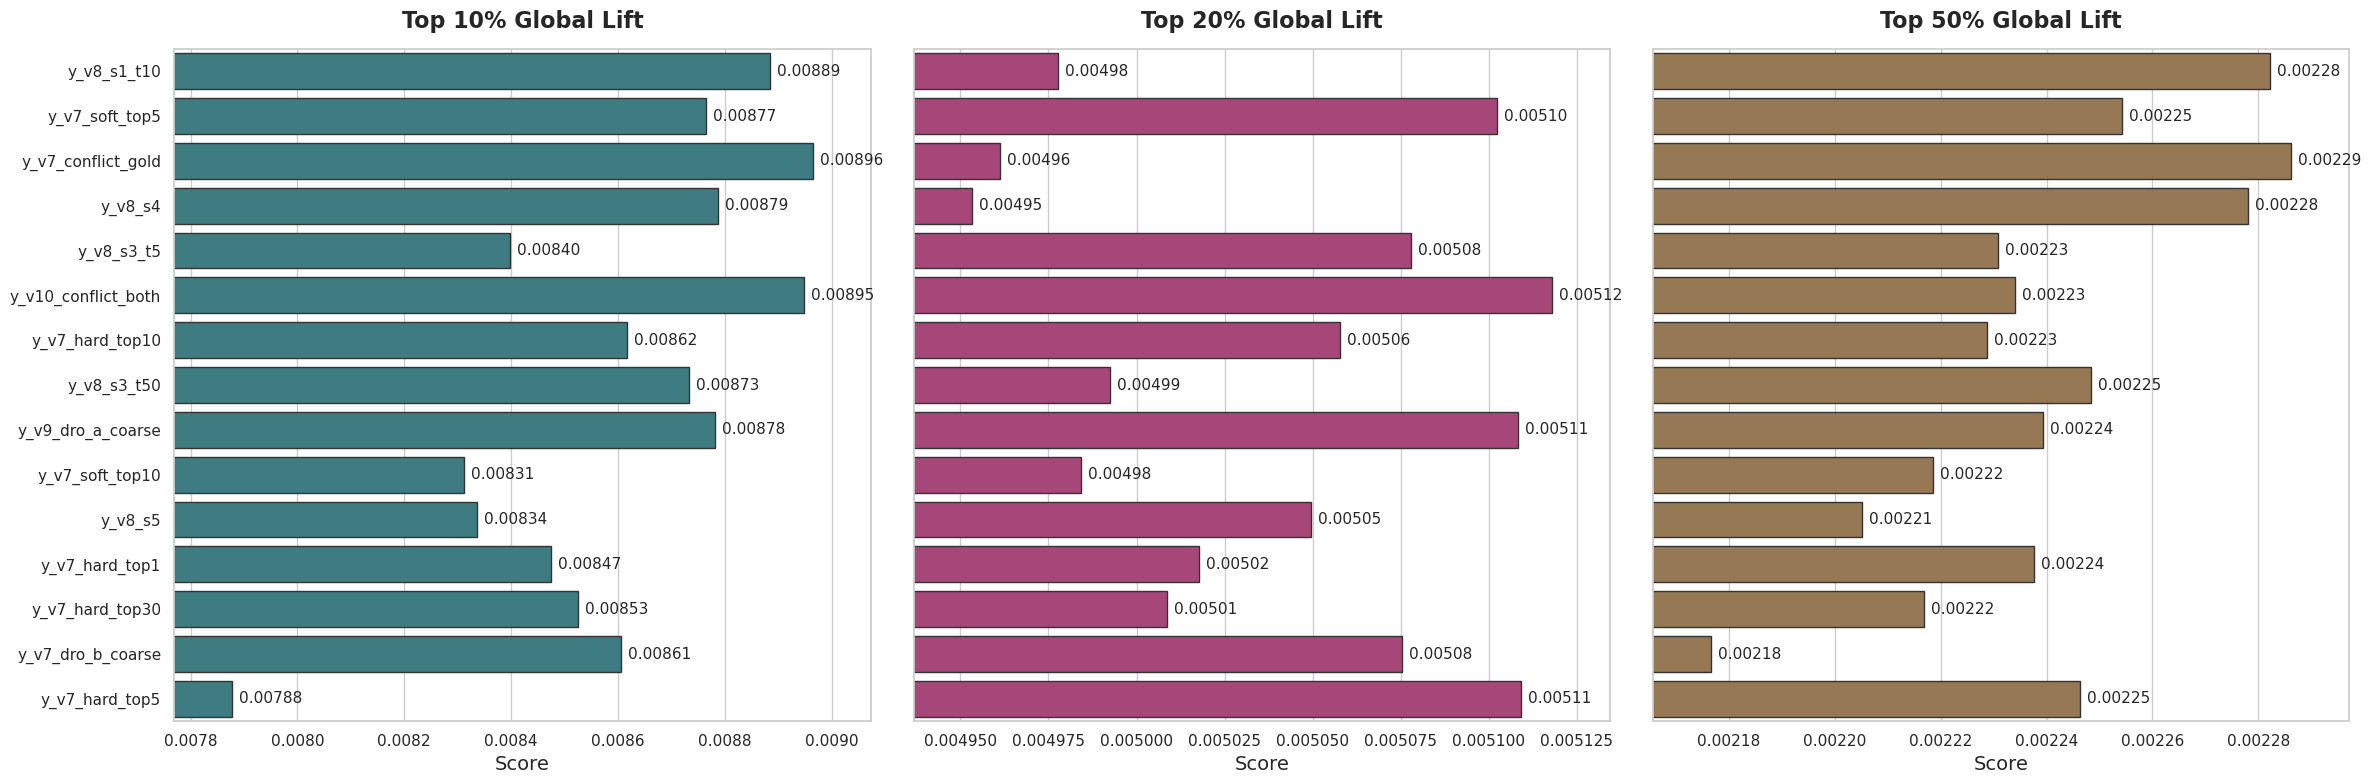

In [20]:
# ==========================================
# 6. 额外补充: 渗透率下探 (Lift@10, Lift@20, Lift@50) 报表与可视化
# ==========================================
print("\n📈 补充表格：大盘渗透率下探 (Lift@10, Lift@20, Lift@50) 及相对 V1 提升")
print("=" * 140)
# 提取补充指标列进行展示 (df_res 依然保持着按 AUUC 降序的绝对排位)
extra_display_cols = [
    "Version", 
    "Lift@10", "Lift@10 (Rel V1%)", 
    "Lift@20", "Lift@20 (Rel V1%)", 
    "Lift@50", "Lift@50 (Rel V1%)"
]
print(df_res[extra_display_cols].to_string(index=False))
print("=" * 140)

print("\n🎨 正在生成补充指标 (Lift@10 / 20 / 50) 绝对值对比图...")

# 新开一张画布，依然是 1行3列
fig2, axes2 = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# 借用已经定义好的 plot_metric 辅助函数，直接画图 (按 AUUC 顺序)
# 第一张：Lift@10 (看核心腰部)
plot_metric(axes2[0], plot_df, "Lift@10", sns.color_palette("crest", 1)[0], "Top 10% Global Lift")

# 第二张：Lift@20 (看普通腰部)
plot_metric(axes2[1], plot_df, "Lift@20", sns.color_palette("magma", 1)[0], "Top 20% Global Lift")

# 第三张：Lift@50 (看大盘半壁江山)
plot_metric(axes2[2], plot_df, "Lift@50", sns.color_palette("cubehelix", 1)[0], "Top 50% Global Lift")

# 排版并落盘
plt.tight_layout()
output_png_extra = "extended_lifts_leaderboard.png"
plt.savefig(output_png_extra, dpi=300, bbox_inches='tight')
print(f"✅ 补充可视化图表已生成: {output_png_extra}")
print("🎉 所有评估流水线彻底执行完毕！")


🌊 补充表格：长尾客群 (Bucket_20_50, Bucket_50_100) 挖掘能力排行榜
            Version  Bucket_20_50  Bucket_20_50 (Rel V1%)  Bucket_50_100  Bucket_50_100 (Rel V1%)
  y_v7_dro_a_coarse        0.0002                 42.8089         0.0002                  89.5423
    y_v7_dro_a_fine       -0.0000               -114.9173         0.0002                  65.9995
        y_v8_s3_t10        0.0001                -57.1697         0.0002                  65.0557
           y_v2_emb        0.0001                -36.0580         0.0002                  56.8426
 y_v7_conflict_wool        0.0000                -90.0821         0.0002                  56.2682
        y_v8_s1_t50        0.0001                -27.8903         0.0002                  49.2794
 y_v7_conflict_both        0.0000                -82.9399         0.0002                  45.7174
     y_v7_soft_top1        0.0000                -68.6833         0.0001                  33.7008
    y_v7_dro_b_fine        0.0001                 13.0157         0

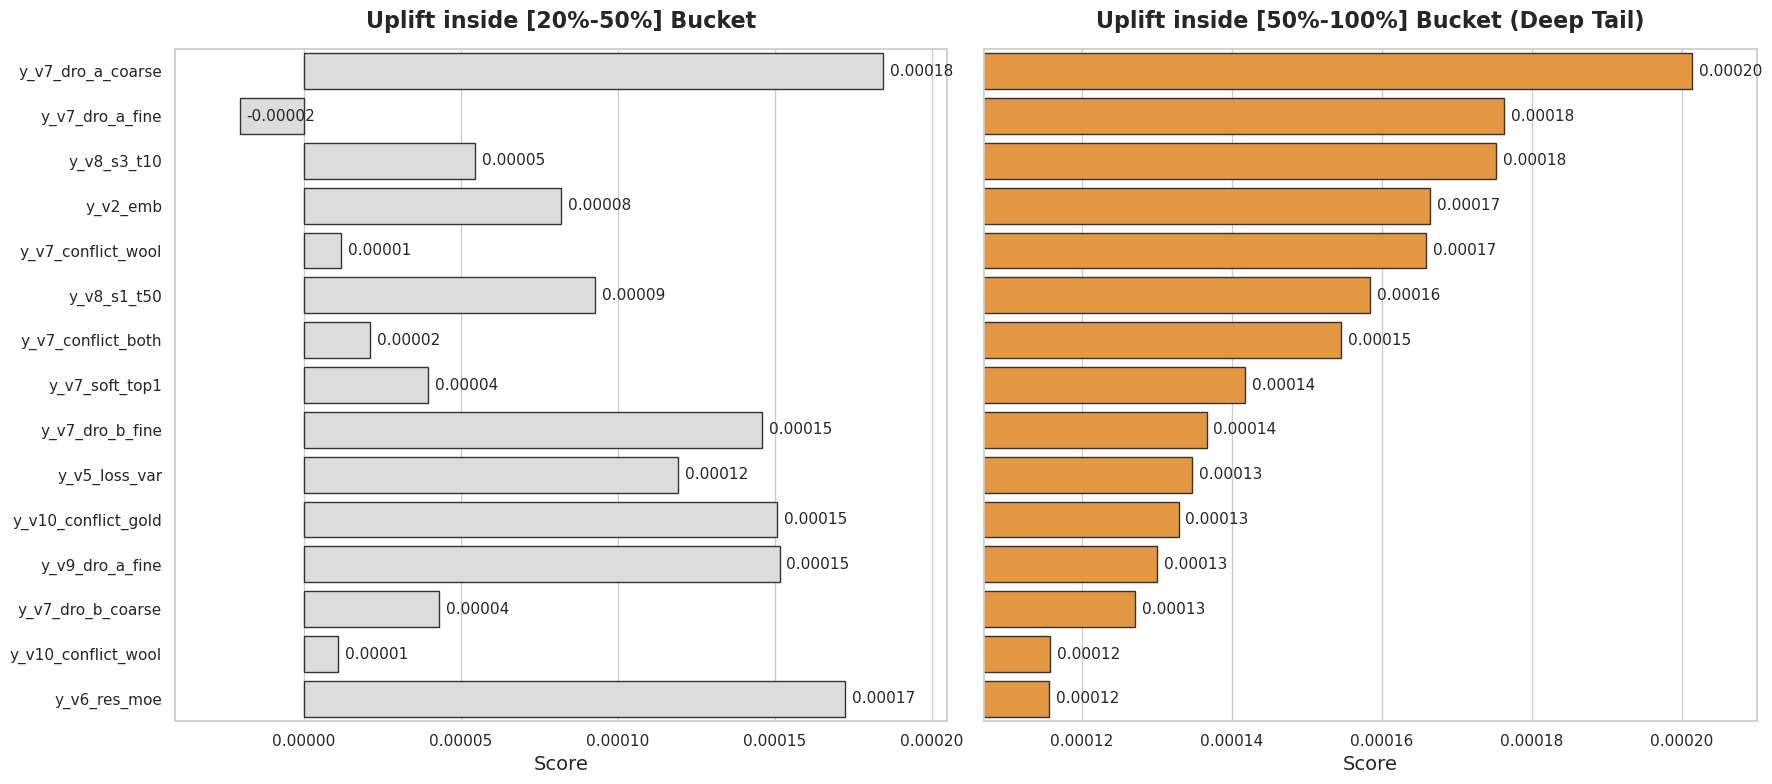

In [21]:
# ==========================================
# 6. 额外补充: 尾部客群 (Tail Buckets) 排序与长尾挖掘能力分析
# 目标：验证 V8_s5 等纯网络模型是否在长尾区具备优势，以及模型单调性是否健康
# ==========================================
print("\n🌊 补充表格：长尾客群 (Bucket_20_50, Bucket_50_100) 挖掘能力排行榜")
print("=" * 140)

# 我们按最深水区 (Bucket_50_100) 来重新降序排列，看看谁是长尾之王
df_tail = df_res.sort_values(by="Bucket_50_100", ascending=False).reset_index(drop=True)

tail_display_cols = [
    "Version", 
    "Bucket_20_50", "Bucket_20_50 (Rel V1%)", 
    "Bucket_50_100", "Bucket_50_100 (Rel V1%)"
]
print(df_tail[tail_display_cols].to_string(index=False))
print("=" * 140)

print("\n🎨 正在生成长尾挖掘能力对比图...")

# 新开一张画布，1行2列
fig3, axes3 = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# 取在尾部表现最好的前 15 名画图
plot_df_tail = df_tail.head(15)

# 画 20-50% (中长尾)
plot_metric(axes3[0], plot_df_tail, "Bucket_20_50", sns.color_palette("coolwarm", 1)[0], "Uplift inside [20%-50%] Bucket")

# 画 50-100% (极度深水区)
plot_metric(axes3[1], plot_df_tail, "Bucket_50_100", sns.color_palette("YlOrBr", 1)[0], "Uplift inside [50%-100%] Bucket (Deep Tail)")

plt.tight_layout()
output_png_tail = "tail_buckets_leaderboard.png"
plt.savefig(output_png_tail, dpi=300, bbox_inches='tight')
print(f"✅ 长尾可视化图表已生成: {output_png_tail}")
print("🎉 所有评估流水线彻底执行完毕！")

🔍 找到了 38 个测试集预测文件，开始执行【局部 AUUC】排行榜分析...

🏆 【大盘统御力】全局 AUUC 与 头部截流 (Lift@5) 🏆
            Version  AUUC (Global)  AUUC (Global) (Rel V1%)  Lift@5  Lift@5 (Rel V1%)
        y_v8_s1_t10         0.9147                   3.4842  0.0133           24.3293
     y_v7_soft_top5         0.9133                   3.3180  0.0127           18.7839
 y_v7_conflict_gold         0.9119                   3.1624  0.0129           20.6241
            y_v8_s4         0.9113                   3.0929  0.0123           14.7010
         y_v8_s3_t5         0.9102                   2.9772  0.0119           11.1597
y_v10_conflict_both         0.9099                   2.9426  0.0135           25.9281
    y_v7_hard_top10         0.9099                   2.9326  0.0126           17.9034
        y_v8_s3_t50         0.9098                   2.9253  0.0130           20.8025
  y_v9_dro_a_coarse         0.9089                   2.8279  0.0138           28.9588
    y_v7_soft_top10         0.9054                   2.4289  0.0

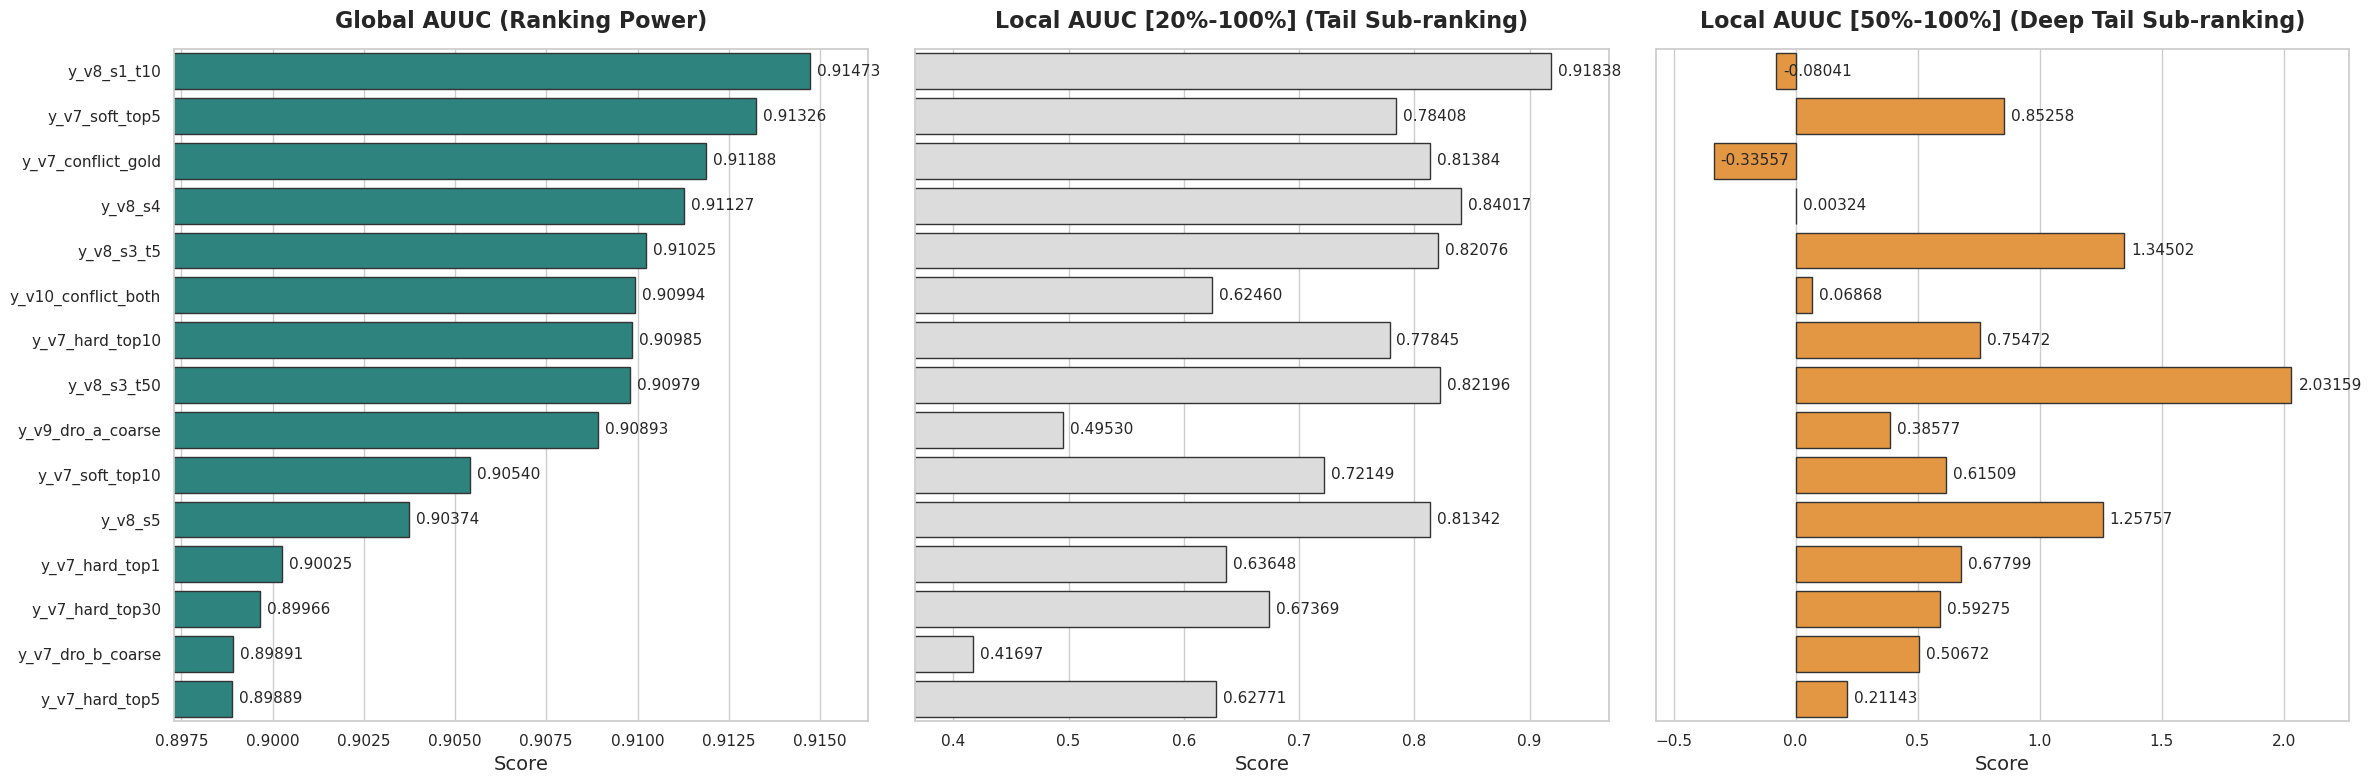

In [22]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 核心算子定义 (融合绝对归一化算法 & 局部 AUUC 引擎)
# ==========================================
def calculate_comprehensive_metrics(y_true, uplift_pred, t):
    """
    计算全局指标 (AUUC, Lift@K) 以及 局部排位指标 (Local AUUC)
    """
    y_true, uplift_pred, t = np.array(y_true), np.array(uplift_pred), np.array(t)
    if len(y_true) == 0: return {}

    # 1. 按预测分数全局降序排列
    order = np.argsort(uplift_pred)[::-1]
    y_true_sorted = y_true[order]
    t_sorted = t[order]
    uplift_pred_sorted = uplift_pred[order]

    # ---------------------------------------------------------
    # [通用基建] 传入切片，计算原味归一化 AUUC
    # ---------------------------------------------------------
    def _compute_auuc_from_slice(y_s, t_s):
        if len(y_s) < 2: return 0.0
        
        n_t_cum = np.cumsum(t_s == 1)
        n_c_cum = np.cumsum(t_s == 0)
        y_t_cum = np.cumsum(y_s * (t_s == 1))
        y_c_cum = np.cumsum(y_s * (t_s == 0))

        n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
        n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)
        x_axis = np.arange(1, len(y_s) + 1) / len(y_s)

        with np.errstate(invalid='ignore', divide='ignore'):
            uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
        uplift_curve = np.nan_to_num(uplift_curve)
        
        # 🌟 防御性归一化：尾部切片的终点经常是负数，必须除以绝对值，否则曲线会上下翻转！
        endpoint = uplift_curve[-1]
        if abs(endpoint) > 1e-10:
            uplift_curve = uplift_curve / abs(endpoint) 
            
        return float(np.trapz(uplift_curve, x=x_axis))

    # ---------------------------------------------------------
    # [全局指标]
    # ---------------------------------------------------------
    global_auuc = _compute_auuc_from_slice(y_true_sorted, t_sorted)
    
    def get_lift_at_k(k_pct):
        idx = int(len(y_true) * k_pct / 100.0)
        if idx == 0: return 0.0
        cr_t = np.sum(y_true_sorted[:idx] * (t_sorted[:idx] == 1)) / (np.sum(t_sorted[:idx] == 1) + 1e-6)
        cr_c = np.sum(y_true_sorted[:idx] * (t_sorted[:idx] == 0)) / (np.sum(t_sorted[:idx] == 0) + 1e-6)
        return float(cr_t - cr_c)

    # ---------------------------------------------------------
    # [细化指标] 局部 AUUC (评估模型在其认定的特定区间内的内部排序能力)
    # ---------------------------------------------------------
    def get_local_auuc(start_pct, end_pct):
        start_idx = int(len(y_true) * start_pct / 100.0)
        end_idx = int(len(y_true) * end_pct / 100.0)
        
        # 物理切断：把这群人关进小黑屋，单独看模型在这群人内部的排序能力
        y_slice = y_true_sorted[start_idx:end_idx]
        t_slice = t_sorted[start_idx:end_idx]
        return _compute_auuc_from_slice(y_slice, t_slice)

    return {
        "AUUC (Global)": global_auuc,
        "Lift@5": get_lift_at_k(5),
        "Lift@10": get_lift_at_k(10),
        "Lift@20": get_lift_at_k(20),
        "Lift@50": get_lift_at_k(50),
        "Local_AUUC [0-5]": get_local_auuc(0, 5),
        "Local_AUUC [5-10]": get_local_auuc(5, 10),
        "Local_AUUC [10-20]": get_local_auuc(10, 20),
        "Local_AUUC [20-50]": get_local_auuc(20, 50),
        "Local_AUUC [50-100]": get_local_auuc(50, 100),
        "Local_AUUC [20-100]": get_local_auuc(20, 100) # 🌟 核心：大长尾内部总排序能力
    }

# ==========================================
# 2. 扫描数据并进行全局测评
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
BASELINE_VERSION = "y_v1_base"

csv_files = glob.glob(os.path.join(BASE_DIR, "**", "test_dist.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError("没有找到任何 test_dist.csv，请检查路径。")

print(f"🔍 找到了 {len(csv_files)} 个测试集预测文件，开始执行【局部 AUUC】排行榜分析...")

results = []
baseline_metrics = None

for file in csv_files:
    version_name = file.split("TARNET/")[1].split("/")[0]
    try:
        df = pd.read_csv(file)
        metrics = calculate_comprehensive_metrics(
            y_true=df['y_true'].values, 
            uplift_pred=df['uplift_pred'].values, 
            t=df['t'].values
        )
        metrics["Version"] = version_name
        results.append(metrics)
        if version_name == BASELINE_VERSION:
            baseline_metrics = metrics
    except Exception as e:
        print(f"❌ 读取 {version_name} 失败: {e}")

df_res = pd.DataFrame(results)

# ==========================================
# 3. 计算相对 V1 的 Relative Improvement
# ==========================================
def calc_relative(val, base_val):
    return (val - base_val) / (abs(base_val) + 1e-6) * 100.0

if baseline_metrics is not None:
    cols_to_compare = [
        "AUUC (Global)", "Lift@5", "Lift@10", "Lift@20", "Lift@50",
        "Local_AUUC [0-5]", "Local_AUUC [5-10]", "Local_AUUC [10-20]", 
        "Local_AUUC [20-50]", "Local_AUUC [50-100]", "Local_AUUC [20-100]"
    ]
    for col in cols_to_compare:
        base_val = baseline_metrics[col]
        df_res[f"{col} (Rel V1%)"] = df_res[col].apply(lambda x: calc_relative(x, base_val))

# ==========================================
# 4. 排序与落盘
# ==========================================
# 🌟 按全局归一化 AUUC 从高到低排
df_res = df_res.sort_values(by="AUUC (Global)", ascending=False).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n🏆 【大盘统御力】全局 AUUC 与 头部截流 (Lift@5) 🏆")
print("=" * 120)
display_cols_1 = ["Version", "AUUC (Global)", "AUUC (Global) (Rel V1%)", "Lift@5", "Lift@5 (Rel V1%)"]
print(df_res[display_cols_1].to_string(index=False))
print("=" * 120)

print("\n🌊 【长尾深水区排序能力】Local AUUC (抛去头部先验优势后，底层特征的真功夫) 🌊")
print("=" * 150)
display_cols_2 = [
    "Version", 
    "Local_AUUC [20-100]", "Local_AUUC [20-100] (Rel V1%)",
    "Local_AUUC [20-50]", "Local_AUUC [20-50] (Rel V1%)",
    "Local_AUUC [50-100]"
]
# 按大长尾能力单独排个序打印出来看看
print(df_res.sort_values(by="Local_AUUC [20-100]", ascending=False)[display_cols_2].to_string(index=False))
print("=" * 150)

output_csv = "local_auuc_leaderboard.csv"
df_res.to_csv(output_csv, index=False)
print(f"✅ 全量数据已存至: {output_csv}")

# ==========================================
# 5. 论文级可视化画图
# ==========================================
print("\n🎨 正在生成 [全局提纯] vs [长尾内部排序] 对比图...")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
plot_df = df_res.head(15) # 取 AUUC 最高的 15 个模型

def plot_metric(ax, data, x_col, color, title):
    sns.barplot(x=x_col, y="Version", data=data, ax=ax, color=color, edgecolor=".2")
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Score", fontsize=14)
    ax.set_ylabel("")
    min_val, max_val = data[x_col].min(), data[x_col].max()
    margin = (max_val - min_val) * 0.1
    ax.set_xlim(min_val - margin, max_val + margin)
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.5f}', (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)

plot_metric(axes[0], plot_df, "AUUC (Global)", sns.color_palette("viridis", 1)[0], "Global AUUC (Ranking Power)")
plot_metric(axes[1], plot_df, "Local_AUUC [20-100]", sns.color_palette("coolwarm", 1)[0], "Local AUUC [20%-100%] (Tail Sub-ranking)")
plot_metric(axes[2], plot_df, "Local_AUUC [50-100]", sns.color_palette("YlOrBr", 1)[0], "Local AUUC [50%-100%] (Deep Tail Sub-ranking)")

plt.tight_layout()
output_png = "local_auuc_tail_analysis.png"
plt.savefig(output_png, dpi=300, bbox_inches='tight')
print(f"✅ 长尾微观排序能力图表已生成: {output_png}")

In [23]:
print(df_res)

    AUUC (Global)  Lift@5  Lift@10  Lift@20  Lift@50  Local_AUUC [0-5]  Local_AUUC [5-10]  Local_AUUC [10-20]  Local_AUUC [20-50]  Local_AUUC [50-100]  Local_AUUC [20-100]              Version  AUUC (Global) (Rel V1%)  Lift@5 (Rel V1%)  Lift@10 (Rel V1%)  Lift@20 (Rel V1%)  Lift@50 (Rel V1%)  Local_AUUC [0-5] (Rel V1%)  Local_AUUC [5-10] (Rel V1%)  Local_AUUC [10-20] (Rel V1%)  Local_AUUC [20-50] (Rel V1%)  Local_AUUC [50-100] (Rel V1%)  Local_AUUC [20-100] (Rel V1%)
0          0.9147  0.0133   0.0089   0.0050   0.0023            0.6012             0.5063              0.7805              0.5074              -0.0804               0.9184          y_v8_s1_t10                   3.4842           24.3293             3.0439             1.4247             5.5951                    -13.3873                      -9.1933                       -6.1928                       -4.2934                      -119.9926                        86.1551
1          0.9133  0.0127   0.0088   0.0051   0.0023    

✅ 解密图表已生成: auuc_paradox_explained.png


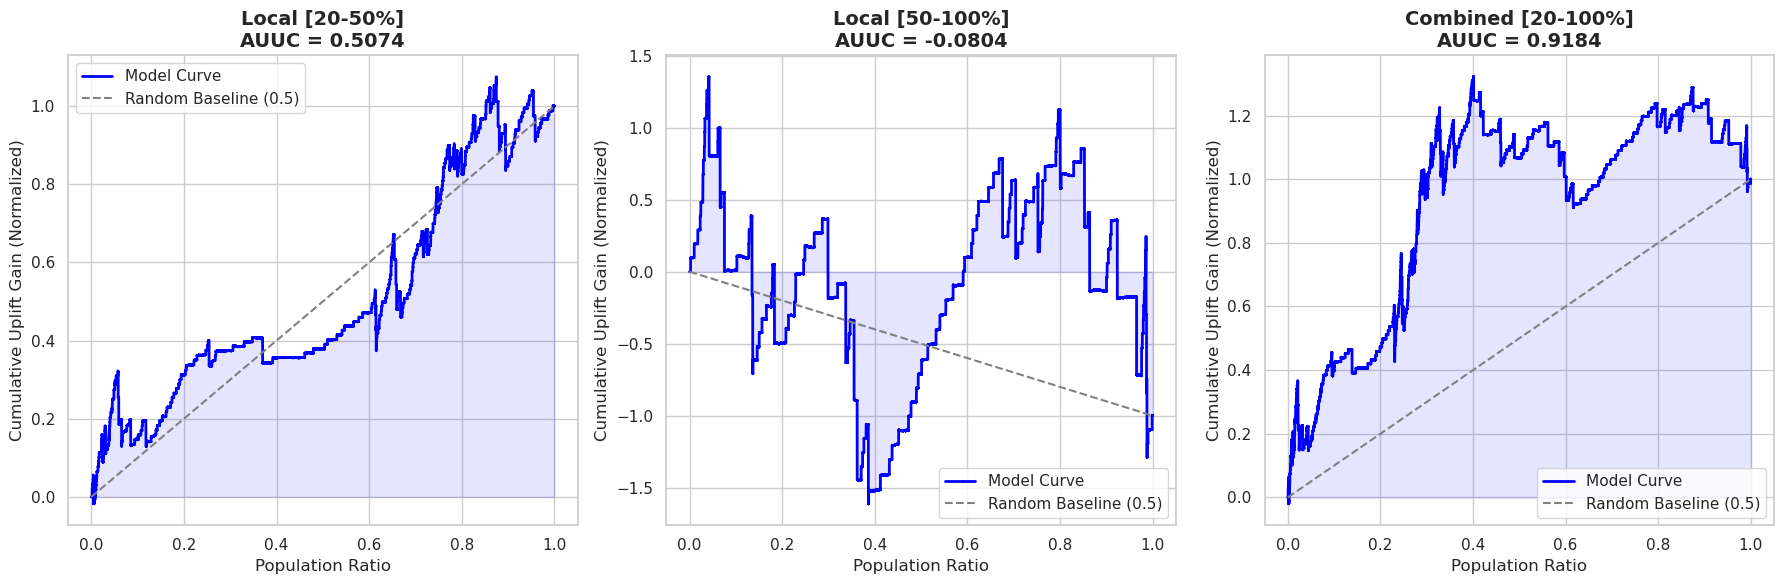

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 指定你看中的那个“奇葩”模型的数据路径
FILE_PATH = "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v8_s1_t10/run_v8_s1_t10/test_dist.csv"

# 1. 核心算子：返回画曲线用的 X 和 Y 坐标
def get_auuc_curve(y_s, t_s):
    if len(y_s) < 2: return [], []
    n_t_cum = np.cumsum(t_s == 1)
    n_c_cum = np.cumsum(t_s == 0)
    y_t_cum = np.cumsum(y_s * (t_s == 1))
    y_c_cum = np.cumsum(y_s * (t_s == 0))

    n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
    n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)
    x_axis = np.arange(1, len(y_s) + 1) / len(y_s)

    with np.errstate(invalid='ignore', divide='ignore'):
        uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
    uplift_curve = np.nan_to_num(uplift_curve)
    
    endpoint = uplift_curve[-1]
    if abs(endpoint) > 1e-10:
        uplift_curve = uplift_curve / abs(endpoint) # 归一化
        
    return x_axis, uplift_curve, float(np.trapz(uplift_curve, x=x_axis))

# 2. 读取并排序
df = pd.read_csv(FILE_PATH)
df = df.sort_values(by='uplift_pred', ascending=False)
y_true = df['y_true'].values
t = df['t'].values

# 3. 切片
idx_20 = int(len(df) * 0.20)
idx_50 = int(len(df) * 0.50)

# 三个切片的数据
slices = {
    "Local [20-50%]": (y_true[idx_20:idx_50], t[idx_20:idx_50]),
    "Local [50-100%]": (y_true[idx_50:], t[idx_50:]),
    "Combined [20-100%]": (y_true[idx_20:], t[idx_20:])
}

# 4. 画图
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

for i, (name, (y_s, t_s)) in enumerate(slices.items()):
    x, y_curve, auuc_score = get_auuc_curve(y_s, t_s)
    
    plt.subplot(1, 3, i+1)
    plt.plot(x, y_curve, label=f"Model Curve", color='blue', linewidth=2)
    # 画出 AUUC=0.5 的随机基线
    end_y = y_curve[-1] if len(y_curve) > 0 else 0
    plt.plot([0, 1], [0, end_y], linestyle='--', color='gray', label="Random Baseline (0.5)")
    
    plt.fill_between(x, 0, y_curve, color='blue', alpha=0.1)
    plt.title(f"{name}\nAUUC = {auuc_score:.4f}", fontsize=14, fontweight='bold')
    plt.xlabel("Population Ratio")
    plt.ylabel("Cumulative Uplift Gain (Normalized)")
    plt.legend()

plt.tight_layout()
plt.savefig("auuc_paradox_explained.png", dpi=300)
print("✅ 解密图表已生成: auuc_paradox_explained.png")

In [45]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置项
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"

# 你点名的 7 个核心模型
TARGET_VERSIONS = [
    "y_v1_base",            # 原始基线：看看最初的“平原”长啥样
    "y_v2_emb",             # 特征拼接：看看加了先验特征有没有起色
    "y_v3_moe",             # 早期 MoE：看看过拟合是怎么在局部 AUUC 上体现的
    "y_v4_loss_strata",     # 损失加权：验证纯 Loss 调整的效果
    "y_v6_res_moe",         # 残差底座：见证“大山”拔地而起的一刻
    "y_v7_soft_top5",       # 软截断：结构隔离的标杆
    "y_v7_conflict_gold",   # 截断+打捞：头部的极品提纯
    "y_v8_s1_t10",          # 动态演进：目前的大盘总冠军
    "y_v8_s5",              # 纯盲盒：长尾区域的“自由搏击”高手
    "y_v10_conflict_both",  # 显式双向：最强纠偏逻辑
    "y_v9_dro_a_coarse",    # 1D DRO：隐式压榨的代表
    'y_v9_dro_b_fine',
    "y_v7_dro_b_coarse"     # 联合缝合：结构与 Loss 的终极配合
]

# 要切分的 8 个区间 (2行4列)
# 第一行看头部积累: 0-5%, 5-10%, 0-10%, 10-20%
# 第二行看腰尾演化: 0-20%, 20-50%, 50-100%, 20-100%
SLICES = [
    ("0-5%", 0.0, 0.05), ("5-10%", 0.05, 0.10), ("0-10%", 0.0, 0.10), ("10-20%", 0.10, 0.20),
    ("0-20%", 0.0, 0.20), ("20-50%", 0.20, 0.50), ("50-100%", 0.50, 1.00), ("20-100%", 0.20, 1.00)
]

# ==========================================
# 2. 核心算子：返回画图坐标
# ==========================================
def get_auuc_curve(y_s, t_s):
    if len(y_s) < 2: return [], [], 0.0
    n_t_cum = np.cumsum(t_s == 1)
    n_c_cum = np.cumsum(t_s == 0)
    y_t_cum = np.cumsum(y_s * (t_s == 1))
    y_c_cum = np.cumsum(y_s * (t_s == 0))

    n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
    n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)
    x_axis = np.arange(1, len(y_s) + 1) / len(y_s)

    with np.errstate(invalid='ignore', divide='ignore'):
        uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
    uplift_curve = np.nan_to_num(uplift_curve)
    
    endpoint = uplift_curve[-1]
    if abs(endpoint) > 1e-10:
        uplift_curve = uplift_curve / abs(endpoint) # 归一化
        
    return x_axis, uplift_curve, float(np.trapz(uplift_curve, x=x_axis))

# ==========================================
# 3. 遍历模型并画图
# ==========================================
sns.set_theme(style="whitegrid")
output_dir = "anatomy_plots"
os.makedirs(output_dir, exist_ok=True)

print(f"🔍 开始生成 {len(TARGET_VERSIONS)} 个核心模型的八阵图透视...")

for version in TARGET_VERSIONS:
    # 查找对应的 CSV 文件
    search_pattern = os.path.join(BASE_DIR, f"{version}/**/test_dist.csv")
    csv_files = glob.glob(search_pattern, recursive=True)
    
    if not csv_files:
        print(f"⚠️ 找不到模型 {version} 的 test_dist.csv，跳过。")
        continue
        
    file_path = csv_files[0]
    
    # 读取并全局降序
    df = pd.read_csv(file_path)
    df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
    y_true = df['y_true'].values
    t = df['t'].values
    n_total = len(df)
    
    # 开画：2 行 4 列
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle(f"Model Anatomy: {version}", fontsize=22, fontweight='bold', y=1.02)
    
    for idx, (slice_name, start_pct, end_pct) in enumerate(SLICES):
        row = idx // 4
        col = idx % 4
        ax = axes[row, col]
        
        # 物理切片
        start_idx = int(n_total * start_pct)
        end_idx = int(n_total * end_pct)
        y_s = y_true[start_idx:end_idx]
        t_s = t[start_idx:end_idx]
        
        # 计算曲线
        x, y_curve, auuc_score = get_auuc_curve(y_s, t_s)
        
        if len(x) == 0:
            continue
            
        # 绘制曲线
        # 使用不同颜色区分微观区间(局部)和宏观区间(全局累积)
        line_color = 'purple' if start_pct == 0.0 else 'royalblue' 
        ax.plot(x, y_curve, color=line_color, linewidth=2.5, label='Uplift Curve')
        ax.fill_between(x, 0, y_curve, color=line_color, alpha=0.1)
        
        # 绘制随机基线
        end_y = y_curve[-1]
        ax.plot([0, 1], [0, end_y], linestyle='--', color='gray', label='Random (0.5)')
        
        # 标题与排版
        ax.set_title(f"[{slice_name}]\nAUUC = {auuc_score:.4f}", fontsize=15, fontweight='bold')
        ax.set_xlabel("Ratio in Slice", fontsize=12)
        ax.set_ylabel("Normalized Gain", fontsize=12)
        
        # 标出 0 线，方便看有没有跌成负的
        ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
        
    plt.tight_layout()
    out_file = os.path.join(output_dir, f"anatomy_{version}.png")
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ 生成完毕: {out_file}")

print("\n🎉 所有的 8 宫格透视图已存入 anatomy_plots/ 文件夹！")

🔍 开始生成 13 个核心模型的八阵图透视...
✅ 生成完毕: anatomy_plots/anatomy_y_v1_base.png
✅ 生成完毕: anatomy_plots/anatomy_y_v2_emb.png
✅ 生成完毕: anatomy_plots/anatomy_y_v3_moe.png
✅ 生成完毕: anatomy_plots/anatomy_y_v4_loss_strata.png
✅ 生成完毕: anatomy_plots/anatomy_y_v6_res_moe.png
✅ 生成完毕: anatomy_plots/anatomy_y_v7_soft_top5.png
✅ 生成完毕: anatomy_plots/anatomy_y_v7_conflict_gold.png
✅ 生成完毕: anatomy_plots/anatomy_y_v8_s1_t10.png
✅ 生成完毕: anatomy_plots/anatomy_y_v8_s5.png
✅ 生成完毕: anatomy_plots/anatomy_y_v10_conflict_both.png
✅ 生成完毕: anatomy_plots/anatomy_y_v9_dro_a_coarse.png
✅ 生成完毕: anatomy_plots/anatomy_y_v9_dro_b_fine.png
✅ 生成完毕: anatomy_plots/anatomy_y_v7_dro_b_coarse.png

🎉 所有的 8 宫格透视图已存入 anatomy_plots/ 文件夹！


In [2]:
import pandas as pd
df = pd.read_csv('/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv')
print(df.head())

        t  y_true  c_true  y0_prob  y1_prob  uplift_pred  pi_01_prior
0 1.00000 0.00000 0.00000  0.00830  0.00886      0.00056      0.00000
1 1.00000 0.00000 0.00000  0.00490  0.00529      0.00039      0.00000
2 0.00000 0.00000 0.00000  0.00808  0.00859      0.00051      0.00000
3 1.00000 0.00000 0.00000  0.05654  0.08115      0.02461      0.00000
4 1.00000 0.00000 0.00000  0.00388  0.00381     -0.00007      0.00000


🔍 开始生成 13 个核心模型的八阵图透视...
✅ 生成完毕: anatomy_plots/anatomy_y_v1_base_auqc.png
✅ 生成完毕: anatomy_plots/anatomy_y_v2_emb_auqc.png
✅ 生成完毕: anatomy_plots/anatomy_y_v3_moe_auqc.png
✅ 生成完毕: anatomy_plots/anatomy_y_v4_loss_strata_auqc.png
✅ 生成完毕: anatomy_plots/anatomy_y_v6_res_moe_auqc.png
✅ 生成完毕: anatomy_plots/anatomy_y_v7_soft_top5_auqc.png


KeyboardInterrupt: 

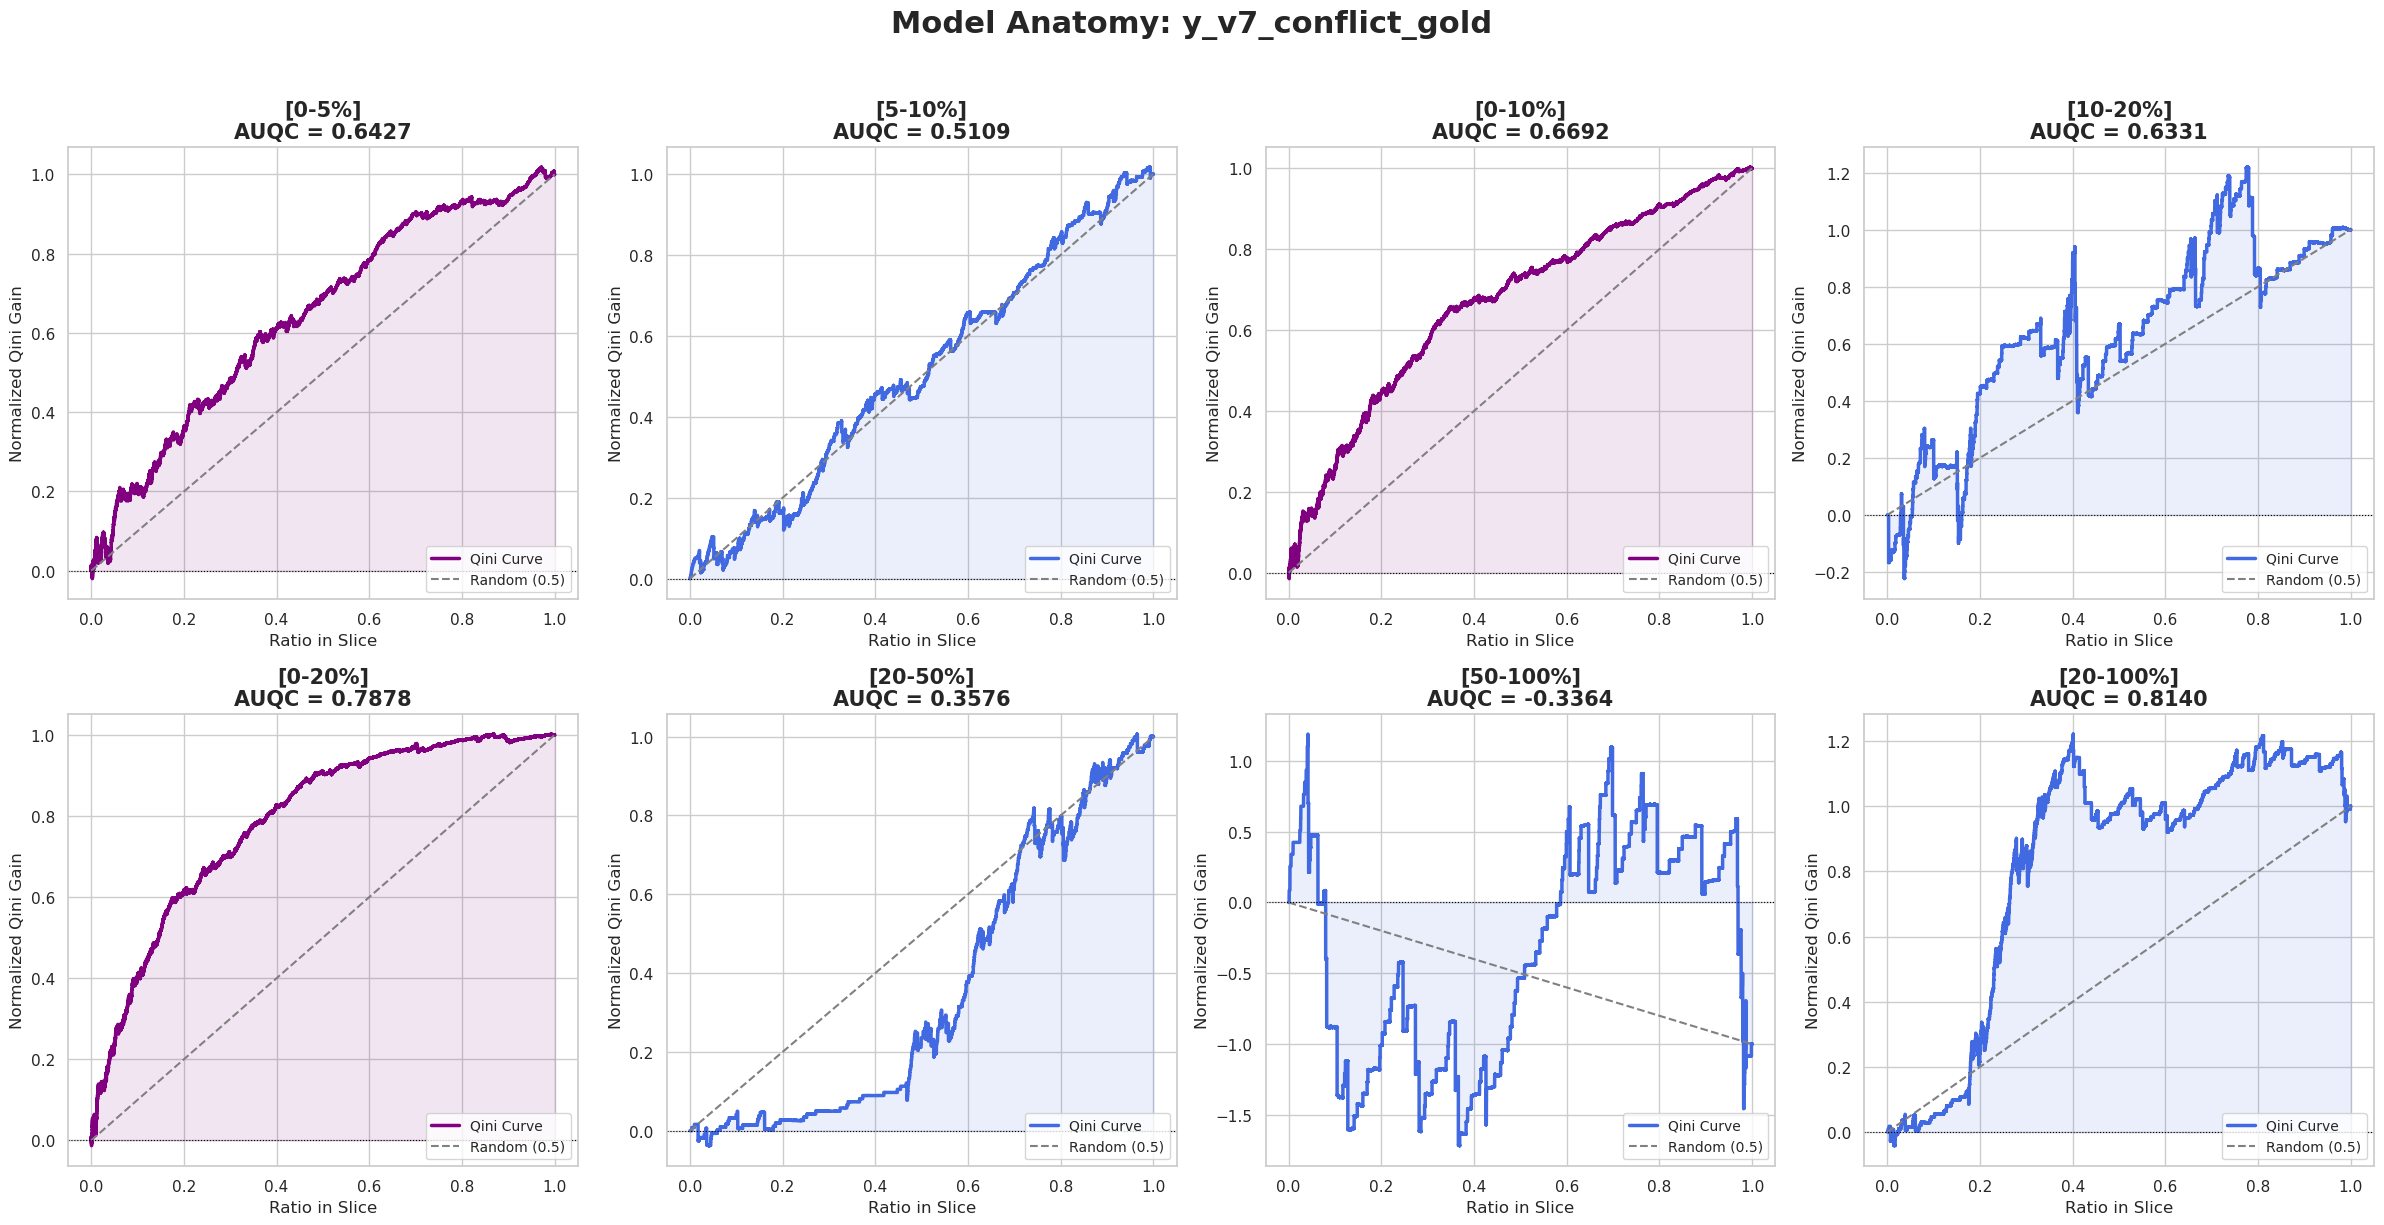

In [44]:
# import os
# import glob
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ==========================================
# # 1. 配置项
# # ==========================================
# BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"

# # 你点名的 7 个核心模型
# TARGET_VERSIONS = [
#     "y_v1_base",            # 原始基线：看看最初的“平原”长啥样
#     "y_v2_emb",             # 特征拼接：看看加了先验特征有没有起色
#     "y_v3_moe",             # 早期 MoE：看看过拟合是怎么在局部 AUUC 上体现的
#     "y_v4_loss_strata",     # 损失加权：验证纯 Loss 调整的效果
#     "y_v6_res_moe",         # 残差底座：见证“大山”拔地而起的一刻
#     "y_v7_soft_top5",       # 软截断：结构隔离的标杆
#     "y_v7_conflict_gold",   # 截断+打捞：头部的极品提纯
#     "y_v8_s1_t10",          # 动态演进：目前的大盘总冠军
#     "y_v8_s5",              # 纯盲盒：长尾区域的“自由搏击”高手
#     "y_v10_conflict_both",  # 显式双向：最强纠偏逻辑
#     "y_v9_dro_a_coarse",    # 1D DRO：隐式压榨的代表
#     'y_v9_dro_b_fine',
#     "y_v7_dro_b_coarse"     # 联合缝合：结构与 Loss 的终极配合
# ]

# # 要切分的 8 个区间 (2行4列)
# # 第一行看头部积累: 0-5%, 5-10%, 0-10%, 10-20%
# # 第二行看腰尾演化: 0-20%, 20-50%, 50-100%, 20-100%
# SLICES = [
#     ("0-5%", 0.0, 0.05), ("5-10%", 0.05, 0.10), ("0-10%", 0.0, 0.10), ("10-20%", 0.10, 0.20),
#     ("0-20%", 0.0, 0.20), ("20-50%", 0.20, 0.50), ("50-100%", 0.50, 1.00), ("20-100%", 0.20, 1.00)
# ]

# # ==========================================
# # 2. 核心算子：返回画图坐标 (修改为 Qini Curve / AUQC)
# # ==========================================
# def get_auqc_curve(y_s, t_s):
#     if len(y_s) < 2: return [], [], 0.0
#     n_t_cum = np.cumsum(t_s == 1)
#     n_c_cum = np.cumsum(t_s == 0)
#     y_t_cum = np.cumsum(y_s * (t_s == 1))
#     y_c_cum = np.cumsum(y_s * (t_s == 0))

#     # n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum) # Qini 公式中分母主要是 n_c
#     n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)
#     x_axis = np.arange(1, len(y_s) + 1) / len(y_s)

#     with np.errstate(invalid='ignore', divide='ignore'):
#         # Qini Curve 核心公式：Y_T - Y_C * (N_T / N_C)
#         qini_curve = y_t_cum - y_c_cum * (n_t_cum / n_c_safe)
#     qini_curve = np.nan_to_num(qini_curve)
    
#     endpoint = qini_curve[-1]
#     if abs(endpoint) > 1e-10:
#         qini_curve = qini_curve / abs(endpoint) # 归一化
        
#     return x_axis, qini_curve, float(np.trapz(qini_curve, x=x_axis))

# # ==========================================
# # 3. 遍历模型并画图
# # ==========================================
# sns.set_theme(style="whitegrid")
# output_dir = "anatomy_plots"
# os.makedirs(output_dir, exist_ok=True)

# print(f"🔍 开始生成 {len(TARGET_VERSIONS)} 个核心模型的八阵图透视...")

# for version in TARGET_VERSIONS:
#     # 查找对应的 CSV 文件
#     search_pattern = os.path.join(BASE_DIR, f"{version}/**/test_dist.csv")
#     csv_files = glob.glob(search_pattern, recursive=True)
    
#     if not csv_files:
#         print(f"⚠️ 找不到模型 {version} 的 test_dist.csv，跳过。")
#         continue
        
#     file_path = csv_files[0]
    
#     # 读取并全局降序
#     df = pd.read_csv(file_path)
#     df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
#     y_true = df['y_true'].values
#     t = df['t'].values
#     n_total = len(df)
    
#     # 开画：2 行 4 列
#     fig, axes = plt.subplots(2, 4, figsize=(24, 12))
#     fig.suptitle(f"Model Anatomy: {version}", fontsize=22, fontweight='bold', y=1.02)
    
#     for idx, (slice_name, start_pct, end_pct) in enumerate(SLICES):
#         row = idx // 4
#         col = idx % 4
#         ax = axes[row, col]
        
#         # 物理切片
#         start_idx = int(n_total * start_pct)
#         end_idx = int(n_total * end_pct)
#         y_s = y_true[start_idx:end_idx]
#         t_s = t[start_idx:end_idx]
        
#         # 计算曲线 (换成 AUQC)
#         x, y_curve, auqc_score = get_auqc_curve(y_s, t_s)
        
#         if len(x) == 0:
#             continue
            
#         # 绘制曲线
#         # 使用不同颜色区分微观区间(局部)和宏观区间(全局累积)
#         line_color = 'purple' if start_pct == 0.0 else 'royalblue' 
#         ax.plot(x, y_curve, color=line_color, linewidth=2.5, label='Qini Curve')
#         ax.fill_between(x, 0, y_curve, color=line_color, alpha=0.1)
        
#         # 绘制随机基线
#         end_y = y_curve[-1]
#         ax.plot([0, 1], [0, end_y], linestyle='--', color='gray', label='Random (0.5)')
        
#         # 标题与排版 (换成 AUQC)
#         ax.set_title(f"[{slice_name}]\nAUQC = {auqc_score:.4f}", fontsize=15, fontweight='bold')
#         ax.set_xlabel("Ratio in Slice", fontsize=12)
#         ax.set_ylabel("Normalized Qini Gain", fontsize=12)
        
#         # 标出 0 线，方便看有没有跌成负的
#         ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
#         ax.legend(loc='lower right', fontsize=10)
        
#     plt.tight_layout()
#     out_file = os.path.join(output_dir, f"anatomy_{version}_auqc.png") # 给输出文件加个标识避免覆盖之前跑的
#     plt.savefig(out_file, dpi=300, bbox_inches='tight')
#     plt.close()
#     print(f"✅ 生成完毕: {out_file}")

# print("\n🎉 所有的 8 宫格透视图已存入 anatomy_plots/ 文件夹！")

In [26]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 1. 核心配置与你点名的观察队列
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"

# 按照“演进史”的顺序排列，方便我们在终端里直接看故事！
TARGET_VERSIONS = [
    "y_v1_base",            # 原始基线
    "y_v2_emb",             # 特征拼接
    "y_v3_moe",             # 早期 MoE
    "y_v4_loss_strata",     # 损失加权
    "y_v6_res_moe",         # 残差底座
    "y_v7_soft_top5",       # 软截断
    "y_v7_conflict_gold",   # 截断+打捞
    "y_v8_s1_t10",          # 动态演进(冠军)
    "y_v8_s5",              # 纯盲盒(长尾杀手)
    "y_v10_conflict_both",  # 显式双向惩罚
    "y_v9_dro_a_coarse",    # 1D DRO粗切
    "y_v9_dro_b_fine",      # 2D DRO细切 (看细切是否过拟合)
    "y_v7_dro_b_coarse"     # 缝合怪
]

# ==========================================
# 2. 计算单个区间的 ATE (Average Treatment Effect)
# ==========================================
def get_bucket_ate(y_true, t, uplift_pred, start_pct, end_pct):
    n_total = len(y_true)
    start_idx = int(n_total * start_pct / 100.0)
    end_idx = int(n_total * end_pct / 100.0)
    
    # 获取切片
    y_slice = y_true[start_idx:end_idx]
    t_slice = t[start_idx:end_idx]
    
    if len(y_slice) == 0: return 0.0
    
    # 避免除以 0
    cr_t = np.sum(y_slice[t_slice == 1]) / (np.sum(t_slice == 1) + 1e-6)
    cr_c = np.sum(y_slice[t_slice == 0]) / (np.sum(t_slice == 0) + 1e-6)
    
    return cr_t - cr_c

# ==========================================
# 3. 遍历提取与报告生成
# ==========================================
print("🔍 正在扫描十二大核心模型的物理分段 ATE...")

results = []

for version in TARGET_VERSIONS:
    search_pattern = os.path.join(BASE_DIR, f"{version}/**/test_dist.csv")
    csv_files = glob.glob(search_pattern, recursive=True)
    
    if not csv_files:
        print(f"⚠️ 找不到: {version} (跳过)")
        continue
        
    file_path = csv_files[0]
    try:
        df = pd.read_csv(file_path)
        # 必须先按模型的 uplift 预测值进行全局降序！
        df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
        
        y_t = df['y_true'].values
        t_t = df['t'].values
        p_t = df['uplift_pred'].values
        
        row = {
            "Version": version,
            "0-5% (金字塔尖)": get_bucket_ate(y_t, t_t, p_t, 0, 5),
            "5-10% (羊毛党灾区)": get_bucket_ate(y_t, t_t, p_t, 5, 10),
            "10-20% (核心腰部)": get_bucket_ate(y_t, t_t, p_t, 10, 20),
            "20-50% (平庸大盘)": get_bucket_ate(y_t, t_t, p_t, 20, 50),
            "50-100% (深水雷区)": get_bucket_ate(y_t, t_t, p_t, 50, 100)
        }
        results.append(row)
    except Exception as e:
        print(f"❌ 读取 {version} 出错: {e}")

df_res = pd.DataFrame(results)

# 打印极度清爽的表格
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
# 放大精度到小数点后 4 位，方便看清微小的增量变化
pd.set_option('display.float_format', '{:.5f}'.format)

print("\n🏆 【十二大金刚】大盘分段真实因果增益 (Bucket ATE) 演进表 🏆")
print("=" * 130)
print(df_res.to_string(index=False))
print("=" * 130)

output_csv = "bucket_ate_evolution.csv"
df_res.to_csv(output_csv, index=False)
print(f"\n✅ 数据已保存至: {output_csv}")
print("💡 观察指南：")
print("1. 看 V1 到 V6: 0-5% 是怎么涨起来的？50-100% 有没有变成负数？")
print("2. 看 V7 和 V8: 0-5% 是不是爆高？同时 20-50% 还有没有维持正向收益？")
print("3. 看 V8_s5: 它的 50-100% 是不是负得极其果断（这说明长尾排雷能力极强）？")

🔍 正在扫描十二大核心模型的物理分段 ATE...

🏆 【十二大金刚】大盘分段真实因果增益 (Bucket ATE) 演进表 🏆
            Version  0-5% (金字塔尖)  5-10% (羊毛党灾区)  10-20% (核心腰部)  20-50% (平庸大盘)  50-100% (深水雷区)
          y_v1_base      0.01073        0.00530        0.00054        0.00013         0.00011
           y_v2_emb      0.01148        0.00356        0.00185        0.00008         0.00017
           y_v3_moe      0.01278        0.00152        0.00065        0.00010         0.00005
   y_v4_loss_strata      0.01210        0.00372        0.00115        0.00022         0.00006
       y_v6_res_moe      0.01471        0.00165        0.00037        0.00017         0.00012
     y_v7_soft_top5      0.01274        0.00394        0.00074        0.00014         0.00001
 y_v7_conflict_gold      0.01294        0.00362        0.00036        0.00035        -0.00002
        y_v8_s1_t10      0.01334        0.00281        0.00045        0.00024        -0.00002
            y_v8_s5      0.01094        0.00445        0.00106        0.00008         0.

In [27]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 1. 核心配置
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"

TARGET_VERSIONS = [
    "y_v1_base", "y_v2_emb", "y_v3_moe", "y_v4_loss_strata",
    "y_v6_res_moe", "y_v7_soft_top5", "y_v7_conflict_gold",
    "y_v8_s1_t10", "y_v8_s5", "y_v10_conflict_both",
    "y_v9_dro_a_coarse", "y_v9_dro_b_fine", "y_v7_dro_b_coarse"
]

SLICES = [(0, 5), (5, 10), (10, 20), (20, 30), (30,50),  (50, 75), (75, 100)]

# ==========================================
# 2. 预加载参考先验 (从 V6 提取真值)
# ==========================================
print("📥 提取 V6 作为参考先验...")
ref_files = glob.glob(os.path.join(BASE_DIR, "y_v6_res_moe/**/test_dist.csv"), recursive=True)
df_ref = pd.read_csv(ref_files[0])
# 假设列名是 p_complier
TRUE_PRIOR = df_ref['pi_01_prior'].values 
print(f"✅ 提取完成，样本数: {len(TRUE_PRIOR)}")

# ==========================================
# 3. 扫描分析
# ==========================================
results = []

for version in TARGET_VERSIONS:
    search_pattern = os.path.join(BASE_DIR, f"{version}/**/test_dist.csv")
    csv_files = glob.glob(search_pattern, recursive=True)
    
    if not csv_files: continue
        
    try:
        df = pd.read_csv(csv_files[0])
        
        # 🌟 针对 V1 这种列全为 0 的情况，强行注入真值
        if version == "y_v1_base" or df['pi_01_prior'].sum() == 0:
            df['pi_01_prior'] = TRUE_PRIOR
            
        # 按各自模型的 uplift 预测值排序
        df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
        
        row = {"Version": version}
        for start, end in SLICES:
            s_idx, e_idx = int(len(df)*start/100), int(len(df)*end/100)
            avg_prior = df['pi_01_prior'].iloc[s_idx:e_idx].mean()
            row[f"{start}-{end}%"] = avg_prior
            
        results.append(row)
    except Exception as e:
        print(f"❌ {version} 报错: {e}")

df_res = pd.DataFrame(results)
pd.set_option('display.float_format', '{:.4f}'.format)
print("\n🧠 【先验服从度】大考排行榜 (数值代表该区间内人群的平均 Prior Pi_01)")
print("=" * 120)
print(df_res.to_string(index=False))
print("=" * 120)

📥 提取 V6 作为参考先验...


✅ 提取完成，样本数: 1397960

🧠 【先验服从度】大考排行榜 (数值代表该区间内人群的平均 Prior Pi_01)
            Version   0-5%  5-10%  10-20%  20-30%  30-50%  50-75%  75-100%
          y_v1_base 0.0635 0.0252  0.0132  0.0047  0.0011  0.0011   0.0038
           y_v2_emb 0.0400 0.0327  0.0191  0.0019  0.0008  0.0011   0.0060
           y_v3_moe 0.0874 0.0263  0.0112  0.0054  0.0010  0.0005   0.0000
   y_v4_loss_strata 0.0500 0.0251  0.0185  0.0085  0.0020  0.0008   0.0026
       y_v6_res_moe 0.0670 0.0262  0.0149  0.0050  0.0010  0.0005   0.0028
     y_v7_soft_top5 0.0624 0.0294  0.0174  0.0070  0.0024  0.0007   0.0000
 y_v7_conflict_gold 0.0623 0.0199  0.0117  0.0009  0.0097  0.0009   0.0006
        y_v8_s1_t10 0.0694 0.0221  0.0135  0.0038  0.0058  0.0007   0.0002
            y_v8_s5 0.0656 0.0243  0.0163  0.0121  0.0011  0.0005   0.0000
y_v10_conflict_both 0.0638 0.0206  0.0189  0.0026  0.0059  0.0003   0.0003
  y_v9_dro_a_coarse 0.0557 0.0257  0.0198  0.0007  0.0015  0.0012   0.0038
    y_v9_dro_b_fine 0.0541 0.0282  0

📥 提取 V6 作为全局参考先验...


✅ 提取完成，样本数: 1397960

🔍 开始四维透视数据提取...
✅ 生成 y_v1_base 剖视图: four_dim_anatomy_y_v1_base.png


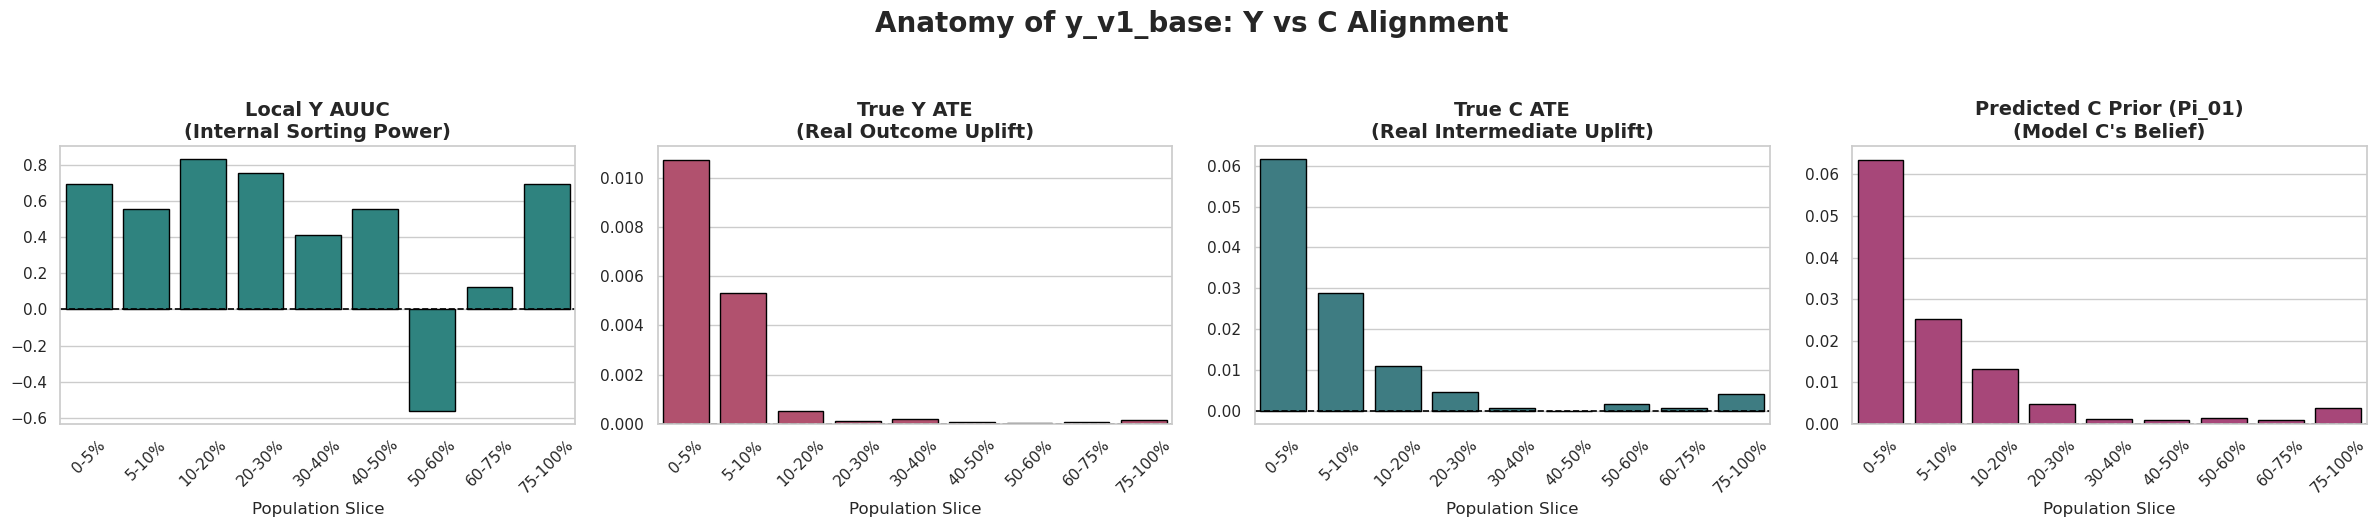

In [28]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 核心配置
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
# 我们先重点解剖 V1，但代码支持随时传入其他版本
TARGET_VERSIONS = [   "y_v1_base", "y_v2_emb", "y_v3_moe", "y_v4_loss_strata",
    "y_v6_res_moe", "y_v7_soft_top5", "y_v7_conflict_gold",
    "y_v8_s1_t10", "y_v8_s5", "y_v10_conflict_both",
    "y_v9_dro_a_coarse", "y_v9_dro_b_fine", "y_v7_dro_b_coarse"] 

SLICES = [(0, 5), (5, 10), (10, 20), (20, 30), (30, 40), (40, 50), (50, 60), (60, 75), (75, 100)]

# ⚠️ 请根据你的实际数据集修改这里真实中介变量 C 的列名！
# 如果没有真实 C，请设为 None
TRUE_C_COLUMN = 'c_true' # 比如 'visit', 'click' 等

# ==========================================
# 2. 算子定义
# ==========================================
def _compute_auuc_from_slice(y_s, t_s):
    if len(y_s) < 2: return 0.0
    n_t_cum = np.cumsum(t_s == 1)
    n_c_cum = np.cumsum(t_s == 0)
    y_t_cum = np.cumsum(y_s * (t_s == 1))
    y_c_cum = np.cumsum(y_s * (t_s == 0))

    n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
    n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)
    x_axis = np.arange(1, len(y_s) + 1) / len(y_s)

    with np.errstate(invalid='ignore', divide='ignore'):
        uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
    uplift_curve = np.nan_to_num(uplift_curve)
    
    endpoint = uplift_curve[-1]
    if abs(endpoint) > 1e-10:
        uplift_curve = uplift_curve / abs(endpoint) 
    return float(np.trapz(uplift_curve, x=x_axis))

def get_ate(y_s, t_s):
    if len(y_s) == 0: return 0.0
    cr_t = np.sum(y_s[t_s == 1]) / (np.sum(t_s == 1) + 1e-6)
    cr_c = np.sum(y_s[t_s == 0]) / (np.sum(t_s == 0) + 1e-6)
    return float(cr_t - cr_c)

# ==========================================
# 3. 提取全局参考先验 (从 V6 提取)
# ==========================================
print("📥 提取 V6 作为全局参考先验...")
ref_files = glob.glob(os.path.join(BASE_DIR, "y_v6_res_moe/**/test_dist.csv"), recursive=True)
df_ref = pd.read_csv(ref_files[0])
prior_col_name = 'p_complier' if 'p_complier' in df_ref.columns else 'pi_01_prior'
TRUE_PRIOR = df_ref[prior_col_name].values 
print(f"✅ 提取完成，样本数: {len(TRUE_PRIOR)}")

# ==========================================
# 4. 数据扫描与提取
# ==========================================
print("\n🔍 开始四维透视数据提取...")
all_results = []

for version in TARGET_VERSIONS:
    search_pattern = os.path.join(BASE_DIR, f"{version}/**/test_dist.csv")
    csv_files = glob.glob(search_pattern, recursive=True)
    if not csv_files: continue
        
    df = pd.read_csv(csv_files[0])
    
    # 强行注入真值先验 (为了让 V1 也能看到先验分布)
    if prior_col_name not in df.columns or df[prior_col_name].sum() == 0:
        df[prior_col_name] = TRUE_PRIOR
        
    # 全局降序
    df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
    
    for start, end in SLICES:
        s_idx, e_idx = int(len(df)*start/100), int(len(df)*end/100)
        
        slice_df = df.iloc[s_idx:e_idx]
        t_s = slice_df['t'].values
        y_s = slice_df['y_true'].values
        c_pred = slice_df[prior_col_name].mean()
        
        c_true_ate = 0.0
        if TRUE_C_COLUMN in df.columns:
            c_true_ate = get_ate(slice_df[TRUE_C_COLUMN].values, t_s)
            
        all_results.append({
            "Version": version,
            "Slice": f"{start}-{end}%",
            "y_Local_AUUC": _compute_auuc_from_slice(y_s, t_s),
            "y_true_ATE": get_ate(y_s, t_s),
            "c_true_ATE": c_true_ate,
            "c_pred_Prior": c_pred
        })

df_res = pd.DataFrame(all_results)

# ==========================================
# 5. 专属绘图仪: 四维解剖图
# ==========================================
def plot_four_dimensions(df_data, version_name):
    df_plot = df_data[df_data["Version"] == version_name].copy()
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle(f"Anatomy of {version_name}: Y vs C Alignment", fontsize=20, fontweight='bold', y=1.05)
    
    metrics = [
        ("y_Local_AUUC", "Local Y AUUC\n(Internal Sorting Power)", sns.color_palette("viridis", 1)[0]),
        ("y_true_ATE", "True Y ATE\n(Real Outcome Uplift)", sns.color_palette("flare", 1)[0]),
        ("c_true_ATE", "True C ATE\n(Real Intermediate Uplift)", sns.color_palette("crest", 1)[0]),
        ("c_pred_Prior", "Predicted C Prior (Pi_01)\n(Model C's Belief)", sns.color_palette("magma", 1)[0])
    ]
    
    for i, (col, title, color) in enumerate(metrics):
        ax = axes[i]
        sns.barplot(data=df_plot, x="Slice", y=col, ax=ax, color=color, edgecolor="black")
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel("Population Slice")
        ax.set_ylabel("")
        ax.tick_params(axis='x', rotation=45)
        
        # 标出 0 轴（特别是因为 ATE 可能为负）
        ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
        
    plt.tight_layout()
    out_name = f"four_dim_anatomy_{version_name}.png"
    plt.savefig(out_name, dpi=300, bbox_inches='tight')
    print(f"✅ 生成 {version_name} 剖视图: {out_name}")

# 画出 V1 的图
plot_four_dimensions(df_res, "y_v1_base")
# plot_four_dimensions(df_res, "y_v8_s1_t10") # 你可以解开注释，拿 V8 和它对比

✅ 生成 y_v8_s1_t10 剖视图: four_dim_anatomy_y_v8_s1_t10.png


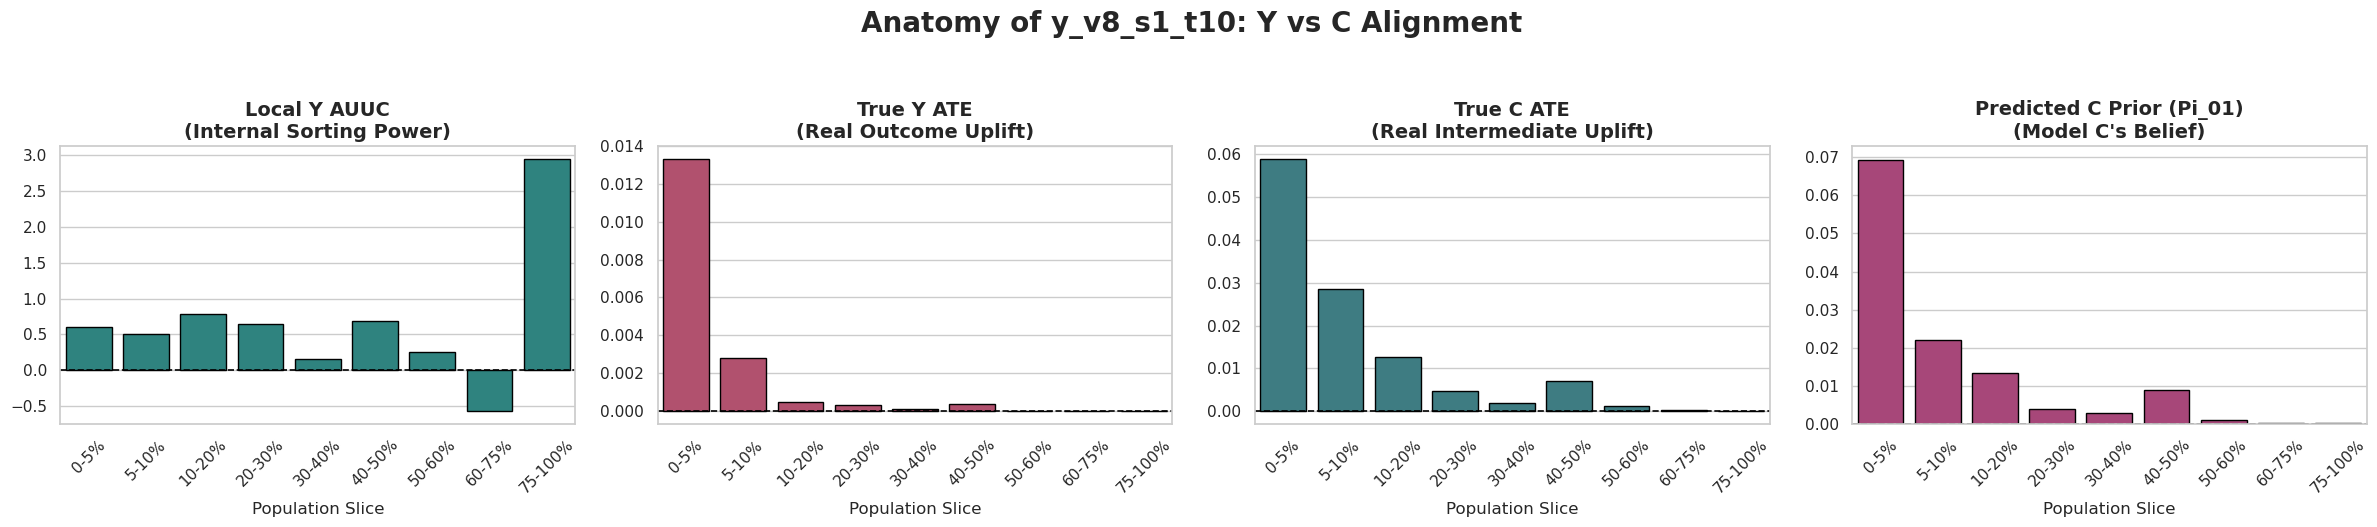

In [29]:
plot_four_dimensions(df_res, "y_v8_s1_t10") # 你可以解开注释，拿 V8 和它对比

In [46]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 1. 核心配置
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
VERSION = "y_v8_s1_t10" # 我们拿大盘总冠军开刀

SLICES = [
    (0, 5), (5, 10), (10, 20),  # (20, 100) 
    (20, 30), (30, 40), (40, 50), (50, 60), (60, 75), (75, 100)
]

# ==========================================
# 2. 扫描与计算
# ==========================================
print(f"🔍 正在启动 {VERSION} 的统计学显微镜...")

search_pattern = os.path.join(BASE_DIR, f"{VERSION}/**/test_dist.csv")
csv_files = glob.glob(search_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError(f"找不到 {VERSION} 的 test_dist.csv")

df = pd.read_csv(csv_files[0])
# 必须先按预测的 uplift 降序排列！
df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)

y_true = df['y_true'].values
t = df['t'].values
n_total = len(df)

results = []

for start_pct, end_pct in SLICES:
    start_idx = int(n_total * start_pct / 100.0)
    end_idx = int(n_total * end_pct / 100.0)
    
    y_slice = y_true[start_idx:end_idx]
    t_slice = t[start_idx:end_idx]
    
    # 基础统计量
    N = len(y_slice)
    if N == 0: continue
        
    N_T = np.sum(t_slice == 1)
    N_C = np.sum(t_slice == 0)
    
    Y_T = np.sum(y_slice[t_slice == 1])
    Y_C = np.sum(y_slice[t_slice == 0])
    
    CR_T = Y_T / (N_T + 1e-9)
    CR_C = Y_C / (N_C + 1e-9)
    
    ATE = CR_T - CR_C
    
    # 方差与标准误估计
    Var_T = (CR_T * (1 - CR_T)) / (N_T + 1e-9)
    Var_C = (CR_C * (1 - CR_C)) / (N_C + 1e-9)
    Var_ATE = Var_T + Var_C
    SE_ATE = np.sqrt(Var_ATE)
    
    # 计算 95% 置信区间的绝对误差界限 (Margin of Error)
    MoE = 1.96 * SE_ATE
    
    # 显著性判断：如果 ATE 的绝对值大于 MoE，说明统计显著
    is_significant = "✅ Yes" if abs(ATE) > MoE else "❌ No (Noise)"
    
    results.append({
        "Slice (%)": f"{start_pct}-{end_pct}",
        "N (Total)": N,
        "N_T | N_C": f"{N_T} | {N_C}",
        "Y_T | Y_C": f"{Y_T} | {Y_C}",
        "CR_T": CR_T,
        "CR_C": CR_C,
        "ATE (Uplift)": ATE,
        "Std. Error": SE_ATE,
        "95% CI bounds": f"± {MoE:.4f}",
        "Is Significant?": is_significant
    })

df_res = pd.DataFrame(results)

# ==========================================
# 3. 打印精美报告
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.5f}'.format)

print(f"\n🔬 【{VERSION}】分段统计量与方差显著性检验报表 🔬")
print("=" * 145)
print(df_res.to_string(index=False))
print("=" * 145)

🔍 正在启动 y_v8_s1_t10 的统计学显微镜...

🔬 【y_v8_s1_t10】分段统计量与方差显著性检验报表 🔬
Slice (%)  N (Total)      N_T | N_C      Y_T | Y_C    CR_T    CR_C  ATE (Uplift)  Std. Error 95% CI bounds Is Significant?
      0-5      69898   60698 | 9200 2624.0 | 275.0 0.04323 0.02989       0.01334     0.00196      ± 0.0038           ✅ Yes
     5-10      69898  59707 | 10191   408.0 | 41.0 0.00683 0.00402       0.00281     0.00071      ± 0.0014           ✅ Yes
    10-20     139796 119065 | 20731   255.0 | 35.0 0.00214 0.00169       0.00045     0.00032      ± 0.0006    ❌ No (Noise)
    20-30     139796 118327 | 21469     84.0 | 9.0 0.00071 0.00042       0.00029     0.00016      ± 0.0003    ❌ No (Noise)
    30-40     139796 118453 | 21343     50.0 | 7.0 0.00042 0.00033       0.00009     0.00014      ± 0.0003    ❌ No (Noise)
    40-50     139796 118852 | 20944   137.0 | 17.0 0.00115 0.00081       0.00034     0.00022      ± 0.0004    ❌ No (Noise)
    50-60     139796 118909 | 20887     29.0 | 6.0 0.00024 0.00029      -0.

In [1]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 1. 核心配置
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
VERSION = "y_v10_conflict_both" # 我们拿大盘总冠军开刀

SLICES = [
    (0, 5), (5, 10), (10, 20),  # (20, 100) 
    (20, 30), (30, 40), (40, 50), (50, 60), (60, 75), (75, 100)
]

# ==========================================
# 2. 扫描与计算
# ==========================================
print(f"🔍 正在启动 {VERSION} 的统计学显微镜...")

search_pattern = os.path.join(BASE_DIR, f"{VERSION}/**/test_dist.csv")
csv_files = glob.glob(search_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError(f"找不到 {VERSION} 的 test_dist.csv")

df = pd.read_csv(csv_files[0])
# 必须先按预测的 uplift 降序排列！
df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)

y_true = df['y_true'].values
t = df['t'].values
n_total = len(df)

results = []

for start_pct, end_pct in SLICES:
    start_idx = int(n_total * start_pct / 100.0)
    end_idx = int(n_total * end_pct / 100.0)
    
    y_slice = y_true[start_idx:end_idx]
    t_slice = t[start_idx:end_idx]
    
    # 基础统计量
    N = len(y_slice)
    if N == 0: continue
        
    N_T = np.sum(t_slice == 1)
    N_C = np.sum(t_slice == 0)
    
    Y_T = np.sum(y_slice[t_slice == 1])
    Y_C = np.sum(y_slice[t_slice == 0])
    
    CR_T = Y_T / (N_T + 1e-9)
    CR_C = Y_C / (N_C + 1e-9)
    
    ATE = CR_T - CR_C
    
    # 方差与标准误估计
    Var_T = (CR_T * (1 - CR_T)) / (N_T + 1e-9)
    Var_C = (CR_C * (1 - CR_C)) / (N_C + 1e-9)
    Var_ATE = Var_T + Var_C
    SE_ATE = np.sqrt(Var_ATE)
    
    # 计算 95% 置信区间的绝对误差界限 (Margin of Error)
    MoE = 1.96 * SE_ATE
    
    # 显著性判断：如果 ATE 的绝对值大于 MoE，说明统计显著
    is_significant = "✅ Yes" if abs(ATE) > MoE else "❌ No (Noise)"
    
    results.append({
        "Slice (%)": f"{start_pct}-{end_pct}",
        "N (Total)": N,
        "N_T | N_C": f"{N_T} | {N_C}",
        "Y_T | Y_C": f"{Y_T} | {Y_C}",
        "CR_T": CR_T,
        "CR_C": CR_C,
        "ATE (Uplift)": ATE,
        "Std. Error": SE_ATE,
        "95% CI bounds": f"± {MoE:.4f}",
        "Is Significant?": is_significant
    })

df_res = pd.DataFrame(results)

# ==========================================
# 3. 打印精美报告
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.5f}'.format)

print(f"\n🔬 【{VERSION}】分段统计量与方差显著性检验报表 🔬")
print("=" * 145)
print(df_res.to_string(index=False))
print("=" * 145)

🔍 正在启动 y_v10_conflict_both 的统计学显微镜...

🔬 【y_v10_conflict_both】分段统计量与方差显著性检验报表 🔬
Slice (%)  N (Total)      N_T | N_C      Y_T | Y_C    CR_T    CR_C  ATE (Uplift)  Std. Error 95% CI bounds Is Significant?
      0-5      69898   60522 | 9376 2638.0 | 282.0 0.04359 0.03008       0.01351     0.00195      ± 0.0038           ✅ Yes
     5-10      69898  59620 | 10278   381.0 | 36.0 0.00639 0.00350       0.00289     0.00067      ± 0.0013           ✅ Yes
    10-20     139796 118871 | 20925   307.0 | 39.0 0.00258 0.00186       0.00072     0.00033      ± 0.0007           ✅ Yes
    20-30     139796 118367 | 21429     47.0 | 7.0 0.00040 0.00033       0.00007     0.00014      ± 0.0003    ❌ No (Noise)
    30-40     139796 118656 | 21140     77.0 | 7.0 0.00065 0.00033       0.00032     0.00015      ± 0.0003           ✅ Yes
    40-50     139796 119007 | 20789   135.0 | 23.0 0.00113 0.00111       0.00003     0.00025      ± 0.0005    ❌ No (Noise)
    50-60     139796 118573 | 21223     16.0 | 4.0 0.00013 

In [2]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 1. 核心配置
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
VERSION = "y_v9_dro_a_coarse" # 我们拿大盘总冠军开刀

SLICES = [
    (0, 5), (5, 10), (10, 20),  # (20, 100) 
    (20, 30), (30, 40), (40, 50), (50, 60), (60, 75), (75, 100)
]

# ==========================================
# 2. 扫描与计算
# ==========================================
print(f"🔍 正在启动 {VERSION} 的统计学显微镜...")

search_pattern = os.path.join(BASE_DIR, f"{VERSION}/**/test_dist.csv")
csv_files = glob.glob(search_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError(f"找不到 {VERSION} 的 test_dist.csv")

df = pd.read_csv(csv_files[0])
# 必须先按预测的 uplift 降序排列！
df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)

y_true = df['y_true'].values
t = df['t'].values
n_total = len(df)

results = []

for start_pct, end_pct in SLICES:
    start_idx = int(n_total * start_pct / 100.0)
    end_idx = int(n_total * end_pct / 100.0)
    
    y_slice = y_true[start_idx:end_idx]
    t_slice = t[start_idx:end_idx]
    
    # 基础统计量
    N = len(y_slice)
    if N == 0: continue
        
    N_T = np.sum(t_slice == 1)
    N_C = np.sum(t_slice == 0)
    
    Y_T = np.sum(y_slice[t_slice == 1])
    Y_C = np.sum(y_slice[t_slice == 0])
    
    CR_T = Y_T / (N_T + 1e-9)
    CR_C = Y_C / (N_C + 1e-9)
    
    ATE = CR_T - CR_C
    
    # 方差与标准误估计
    Var_T = (CR_T * (1 - CR_T)) / (N_T + 1e-9)
    Var_C = (CR_C * (1 - CR_C)) / (N_C + 1e-9)
    Var_ATE = Var_T + Var_C
    SE_ATE = np.sqrt(Var_ATE)
    
    # 计算 95% 置信区间的绝对误差界限 (Margin of Error)
    MoE = 1.96 * SE_ATE
    
    # 显著性判断：如果 ATE 的绝对值大于 MoE，说明统计显著
    is_significant = "✅ Yes" if abs(ATE) > MoE else "❌ No (Noise)"
    
    results.append({
        "Slice (%)": f"{start_pct}-{end_pct}",
        "N (Total)": N,
        "N_T | N_C": f"{N_T} | {N_C}",
        "Y_T | Y_C": f"{Y_T} | {Y_C}",
        "CR_T": CR_T,
        "CR_C": CR_C,
        "ATE (Uplift)": ATE,
        "Std. Error": SE_ATE,
        "95% CI bounds": f"± {MoE:.4f}",
        "Is Significant?": is_significant
    })

df_res = pd.DataFrame(results)

# ==========================================
# 3. 打印精美报告
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.5f}'.format)

print(f"\n🔬 【{VERSION}】分段统计量与方差显著性检验报表 🔬")
print("=" * 145)
print(df_res.to_string(index=False))
print("=" * 145)

🔍 正在启动 y_v9_dro_a_coarse 的统计学显微镜...

🔬 【y_v9_dro_a_coarse】分段统计量与方差显著性检验报表 🔬
Slice (%)  N (Total)      N_T | N_C      Y_T | Y_C    CR_T    CR_C  ATE (Uplift)  Std. Error 95% CI bounds Is Significant?
      0-5      69898   60349 | 9549 2554.0 | 272.0 0.04232 0.02848       0.01384     0.00189      ± 0.0037           ✅ Yes
     5-10      69898  59687 | 10211   450.0 | 49.0 0.00754 0.00480       0.00274     0.00077      ± 0.0015           ✅ Yes
    10-20     139796 118801 | 20995   314.0 | 37.0 0.00264 0.00176       0.00088     0.00033      ± 0.0006           ✅ Yes
    20-30     139796 118220 | 21576     34.0 | 5.0 0.00029 0.00023       0.00006     0.00011      ± 0.0002    ❌ No (Noise)
    30-40     139796 118460 | 21336     38.0 | 3.0 0.00032 0.00014       0.00018     0.00010      ± 0.0002    ❌ No (Noise)
    40-50     139796 118468 | 21328     22.0 | 2.0 0.00019 0.00009       0.00009     0.00008      ± 0.0002    ❌ No (Noise)
    50-60     139796 118812 | 20984     20.0 | 5.0 0.00017 0.00

In [40]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 1. 核心配置
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
VERSION = "y_v8_s1_t10" # 可以换成 y_v1_base 做对比

SLICES = [
    (0, 5), (5, 10), (10, 20), (20, 30), (30, 40), 
    (40, 50), (50, 60), (60, 75), (75, 100)
]

# ⚠️ 请确认你的真实中介变量列名 (比如 'c_true', 'visit', 'click')
TRUE_C_COLUMN = 'c_true' 

# ==========================================
# 2. 扫描与计算
# ==========================================
print(f"🔍 正在启动 {VERSION} 的【预测 vs 真实】全链路校准透视仪...")

search_pattern = os.path.join(BASE_DIR, f"{VERSION}/**/test_dist.csv")
csv_files = glob.glob(search_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError(f"找不到 {VERSION} 的 test_dist.csv")

df = pd.read_csv(csv_files[0])
# 必须先按预测的 uplift 降序排列！
df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)

y_true = df['y_true'].values
t = df['t'].values

# 确定 C_true 列
if TRUE_C_COLUMN in df.columns:
    c_true = df[TRUE_C_COLUMN].values
else:
    print(f"⚠️ 警告：未找到列 '{TRUE_C_COLUMN}'，请确认你的真实中介列名！")
    c_true = np.zeros_like(y_true)

# 确定预测的 Prior C 列名 (兼顾不同版本的命名习惯)
prior_col = 'p_complier' if 'p_complier' in df.columns else 'pi_01_prior'
if prior_col not in df.columns:
    df[prior_col] = 0.0 # 防御性填充

n_total = len(df)
results = []

for start_pct, end_pct in SLICES:
    start_idx = int(n_total * start_pct / 100.0)
    end_idx = int(n_total * end_pct / 100.0)
    
    slice_df = df.iloc[start_idx:end_idx]
    
    y_slice = slice_df['y_true'].values
    c_slice = slice_df[TRUE_C_COLUMN].values if TRUE_C_COLUMN in df.columns else np.zeros(len(slice_df))
    t_slice = slice_df['t'].values
    
    # 基础统计量
    N = len(y_slice)
    if N == 0: continue
    N_T = np.sum(t_slice == 1)
    N_C = np.sum(t_slice == 0)
    
    # === 真实值 (Ground Truth) ===
    ATE_Y_True = (np.sum(y_slice[t_slice == 1]) / (N_T + 1e-9)) - (np.sum(y_slice[t_slice == 0]) / (N_C + 1e-9))
    ATE_C_True = (np.sum(c_slice[t_slice == 1]) / (N_T + 1e-9)) - (np.sum(c_slice[t_slice == 0]) / (N_C + 1e-9))
    
    # === 预测值 (Model Predictions) ===
    Pred_Y_Uplift = slice_df['uplift_pred'].mean()
    Pred_C_Prior = slice_df[prior_col].mean()
    
    # === 计算校准误差 (预测 - 真实) ===
    # 正数表示高估 (Overconfident)，负数表示低估 (Underconfident)
    Calib_Error_Y = Pred_Y_Uplift - ATE_Y_True
    
    results.append({
        "Slice (%)": f"{start_pct}-{end_pct}",
        "N (Total)": N,
        "True C (ATE)": ATE_C_True,
        "Pred C (Prior)": Pred_C_Prior,
        "|": "|",
        "True Y (ATE)": ATE_Y_True,
        "Pred Y (Uplift)": Pred_Y_Uplift,
        "Y Calib Error": Calib_Error_Y
    })

df_res = pd.DataFrame(results)

# ==========================================
# 3. 打印精美报告
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.5f}'.format)

print(f"\n🔬 【{VERSION}】分段【预测 vs 真实】校准对齐表 🔬")
print("=" * 130)
print(df_res.to_string(index=False))
print("=" * 130)
print("\n💡 破案指南：")
print("1. 完美校准：Pred Y 应该与 True Y 极其接近 (Y Calib Error 趋近于 0)。")
print("2. 尾部幻觉：如果尾部的 True Y 已经是 0.0001，但 Pred Y 还是 0.0050，说明模型在尾部极度自大 (Overconfident)！")
print("3. V8 封神时刻：看看 V8 的 Pred Y 是不是在尾部极其乖巧地趴在 0 附近？这就叫懂得知之为知之，不知为不知！")

🔍 正在启动 y_v8_s1_t10 的【预测 vs 真实】全链路校准透视仪...

🔬 【y_v8_s1_t10】分段【预测 vs 真实】校准对齐表 🔬
Slice (%)  N (Total)  True C (ATE)  Pred C (Prior) |  True Y (ATE)  Pred Y (Uplift)  Y Calib Error
      0-5      69898       0.05892         0.06940 |       0.01334          0.01798        0.00464
     5-10      69898       0.02867         0.02207 |       0.00281          0.00543        0.00262
    10-20     139796       0.01257         0.01347 |       0.00045          0.00272        0.00226
    20-30     139796       0.00473         0.00381 |       0.00029          0.00179        0.00150
    30-40     139796       0.00192         0.00280 |       0.00009          0.00170        0.00160
    40-50     139796       0.00718         0.00889 |       0.00034          0.00096        0.00061
    50-60     139796       0.00125         0.00115 |      -0.00004          0.00050        0.00054
    60-75     209694       0.00026         0.00035 |      -0.00001          0.00041        0.00042
   75-100     349490      -0.00

In [1]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 1. 核心配置
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
VERSION = "y_v8_s5" # 可以换成 y_v1_base 做对比

SLICES = [
    (0, 5), (5, 10), (10, 20), (20, 30), (30, 40), 
    (40, 50), (50, 60), (60, 75), (75, 100)
]

# ⚠️ 请确认你的真实中介变量列名 (比如 'c_true', 'visit', 'click')
TRUE_C_COLUMN = 'c_true' 

# ==========================================
# 2. 扫描与计算
# ==========================================
print(f"🔍 正在启动 {VERSION} 的【预测 vs 真实】全链路校准透视仪...")

search_pattern = os.path.join(BASE_DIR, f"{VERSION}/**/test_dist.csv")
csv_files = glob.glob(search_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError(f"找不到 {VERSION} 的 test_dist.csv")

df = pd.read_csv(csv_files[0])
# 必须先按预测的 uplift 降序排列！
df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)

y_true = df['y_true'].values
t = df['t'].values

# 确定 C_true 列
if TRUE_C_COLUMN in df.columns:
    c_true = df[TRUE_C_COLUMN].values
else:
    print(f"⚠️ 警告：未找到列 '{TRUE_C_COLUMN}'，请确认你的真实中介列名！")
    c_true = np.zeros_like(y_true)

# 确定预测的 Prior C 列名 (兼顾不同版本的命名习惯)
prior_col = 'p_complier' if 'p_complier' in df.columns else 'pi_01_prior'
if prior_col not in df.columns:
    df[prior_col] = 0.0 # 防御性填充

n_total = len(df)
results = []

for start_pct, end_pct in SLICES:
    start_idx = int(n_total * start_pct / 100.0)
    end_idx = int(n_total * end_pct / 100.0)
    
    slice_df = df.iloc[start_idx:end_idx]
    
    y_slice = slice_df['y_true'].values
    c_slice = slice_df[TRUE_C_COLUMN].values if TRUE_C_COLUMN in df.columns else np.zeros(len(slice_df))
    t_slice = slice_df['t'].values
    
    # 基础统计量
    N = len(y_slice)
    if N == 0: continue
    N_T = np.sum(t_slice == 1)
    N_C = np.sum(t_slice == 0)
    
    # === 真实值 (Ground Truth) ===
    ATE_Y_True = (np.sum(y_slice[t_slice == 1]) / (N_T + 1e-9)) - (np.sum(y_slice[t_slice == 0]) / (N_C + 1e-9))
    ATE_C_True = (np.sum(c_slice[t_slice == 1]) / (N_T + 1e-9)) - (np.sum(c_slice[t_slice == 0]) / (N_C + 1e-9))
    
    # === 预测值 (Model Predictions) ===
    Pred_Y_Uplift = slice_df['uplift_pred'].mean()
    Pred_C_Prior = slice_df[prior_col].mean()
    
    # === 计算校准误差 (预测 - 真实) ===
    # 正数表示高估 (Overconfident)，负数表示低估 (Underconfident)
    Calib_Error_Y = Pred_Y_Uplift - ATE_Y_True
    
    results.append({
        "Slice (%)": f"{start_pct}-{end_pct}",
        "N (Total)": N,
        "True C (ATE)": ATE_C_True,
        "Pred C (Prior)": Pred_C_Prior,
        "|": "|",
        "True Y (ATE)": ATE_Y_True,
        "Pred Y (Uplift)": Pred_Y_Uplift,
        "Y Calib Error": Calib_Error_Y
    })

df_res = pd.DataFrame(results)

# ==========================================
# 3. 打印精美报告
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.5f}'.format)

print(f"\n🔬 【{VERSION}】分段【预测 vs 真实】校准对齐表 🔬")
print("=" * 130)
print(df_res.to_string(index=False))
print("=" * 130)
print("\n💡 破案指南：")
print("1. 完美校准：Pred Y 应该与 True Y 极其接近 (Y Calib Error 趋近于 0)。")
print("2. 尾部幻觉：如果尾部的 True Y 已经是 0.0001，但 Pred Y 还是 0.0050，说明模型在尾部极度自大 (Overconfident)！")
print("3. V8 封神时刻：看看 V8 的 Pred Y 是不是在尾部极其乖巧地趴在 0 附近？这就叫懂得知之为知之，不知为不知！")

🔍 正在启动 y_v8_s5 的【预测 vs 真实】全链路校准透视仪...

🔬 【y_v8_s5】分段【预测 vs 真实】校准对齐表 🔬
Slice (%)  N (Total)  True C (ATE)  Pred C (Prior) |  True Y (ATE)  Pred Y (Uplift)  Y Calib Error
      0-5      69898       0.06290         0.06558 |       0.01094          0.04297        0.03203
     5-10      69898       0.02705         0.02426 |       0.00445          0.00896        0.00450
    10-20     139796       0.01364         0.01628 |       0.00106          0.00245        0.00140
    20-30     139796       0.00993         0.01206 |       0.00006          0.00052        0.00046
    30-40     139796       0.00045         0.00088 |       0.00009          0.00014        0.00004
    40-50     139796       0.00117         0.00136 |       0.00007          0.00010        0.00003
    50-60     139796       0.00119         0.00092 |       0.00039         -0.00002       -0.00041
    60-75     209694       0.00052         0.00018 |       0.00005         -0.00009       -0.00014
   75-100     349490      -0.00007     

In [1]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 1. 核心配置
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/"
VERSION = "y_v6_res_moe" # 可以换成 y_v1_base 做对比

SLICES = [
    (0, 5), (5, 10), (10, 20), (20, 30), (30, 40), 
    (40, 50), (50, 60), (60, 75), (75, 100)
]

# ⚠️ 请确认你的真实中介变量列名 (比如 'c_true', 'visit', 'click')
TRUE_C_COLUMN = 'c_true' 

# ==========================================
# 2. 扫描与计算
# ==========================================
print(f"🔍 正在启动 {VERSION} 的【预测 vs 真实】全链路校准透视仪...")

search_pattern = os.path.join(BASE_DIR, f"{VERSION}/**/test_dist.csv")
csv_files = glob.glob(search_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError(f"找不到 {VERSION} 的 test_dist.csv")

df = pd.read_csv(csv_files[0])
# 必须先按预测的 uplift 降序排列！
df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)

y_true = df['y_true'].values
t = df['t'].values

# 确定 C_true 列
if TRUE_C_COLUMN in df.columns:
    c_true = df[TRUE_C_COLUMN].values
else:
    print(f"⚠️ 警告：未找到列 '{TRUE_C_COLUMN}'，请确认你的真实中介列名！")
    c_true = np.zeros_like(y_true)

# 确定预测的 Prior C 列名 (兼顾不同版本的命名习惯)
prior_col = 'p_complier' if 'p_complier' in df.columns else 'pi_01_prior'
if prior_col not in df.columns:
    df[prior_col] = 0.0 # 防御性填充

n_total = len(df)
results = []

for start_pct, end_pct in SLICES:
    start_idx = int(n_total * start_pct / 100.0)
    end_idx = int(n_total * end_pct / 100.0)
    
    slice_df = df.iloc[start_idx:end_idx]
    
    y_slice = slice_df['y_true'].values
    c_slice = slice_df[TRUE_C_COLUMN].values if TRUE_C_COLUMN in df.columns else np.zeros(len(slice_df))
    t_slice = slice_df['t'].values
    
    # 基础统计量
    N = len(y_slice)
    if N == 0: continue
    N_T = np.sum(t_slice == 1)
    N_C = np.sum(t_slice == 0)
    
    # === 真实值 (Ground Truth) ===
    ATE_Y_True = (np.sum(y_slice[t_slice == 1]) / (N_T + 1e-9)) - (np.sum(y_slice[t_slice == 0]) / (N_C + 1e-9))
    ATE_C_True = (np.sum(c_slice[t_slice == 1]) / (N_T + 1e-9)) - (np.sum(c_slice[t_slice == 0]) / (N_C + 1e-9))
    
    # === 预测值 (Model Predictions) ===
    Pred_Y_Uplift = slice_df['uplift_pred'].mean()
    Pred_C_Prior = slice_df[prior_col].mean()
    
    # === 计算校准误差 (预测 - 真实) ===
    # 正数表示高估 (Overconfident)，负数表示低估 (Underconfident)
    Calib_Error_Y = Pred_Y_Uplift - ATE_Y_True
    
    results.append({
        "Slice (%)": f"{start_pct}-{end_pct}",
        "N (Total)": N,
        "True C (ATE)": ATE_C_True,
        "Pred C (Prior)": Pred_C_Prior,
        "|": "|",
        "True Y (ATE)": ATE_Y_True,
        "Pred Y (Uplift)": Pred_Y_Uplift,
        "Y Calib Error": Calib_Error_Y
    })

df_res = pd.DataFrame(results)

# ==========================================
# 3. 打印精美报告
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.5f}'.format)

print(f"\n🔬 【{VERSION}】分段【预测 vs 真实】校准对齐表 🔬")
print("=" * 130)
print(df_res.to_string(index=False))
print("=" * 130)
print("\n💡 破案指南：")
print("1. 完美校准：Pred Y 应该与 True Y 极其接近 (Y Calib Error 趋近于 0)。")
print("2. 尾部幻觉：如果尾部的 True Y 已经是 0.0001，但 Pred Y 还是 0.0050，说明模型在尾部极度自大 (Overconfident)！")
print("3. V8 封神时刻：看看 V8 的 Pred Y 是不是在尾部极其乖巧地趴在 0 附近？这就叫懂得知之为知之，不知为不知！")

🔍 正在启动 y_v6_res_moe 的【预测 vs 真实】全链路校准透视仪...

🔬 【y_v6_res_moe】分段【预测 vs 真实】校准对齐表 🔬
Slice (%)  N (Total)  True C (ATE)  Pred C (Prior) |  True Y (ATE)  Pred Y (Uplift)  Y Calib Error
      0-5      69898       0.05732         0.06697 |       0.01471          0.01301       -0.00170
     5-10      69898       0.03060         0.02623 |       0.00165          0.00096       -0.00069
    10-20     139796       0.01433         0.01493 |       0.00037          0.00025       -0.00013
    20-30     139796       0.00637         0.00496 |       0.00030          0.00005       -0.00025
    30-40     139796       0.00025         0.00082 |       0.00012          0.00003       -0.00010
    40-50     139796       0.00058         0.00120 |       0.00008          0.00002       -0.00006
    50-60     139796       0.00127         0.00068 |       0.00010          0.00001       -0.00009
    60-75     209694       0.00087         0.00038 |       0.00007          0.00001       -0.00006
   75-100     349490       0.

✅ 生成 y_v3_moe 剖视图: four_dim_anatomy_y_v3_moe.png


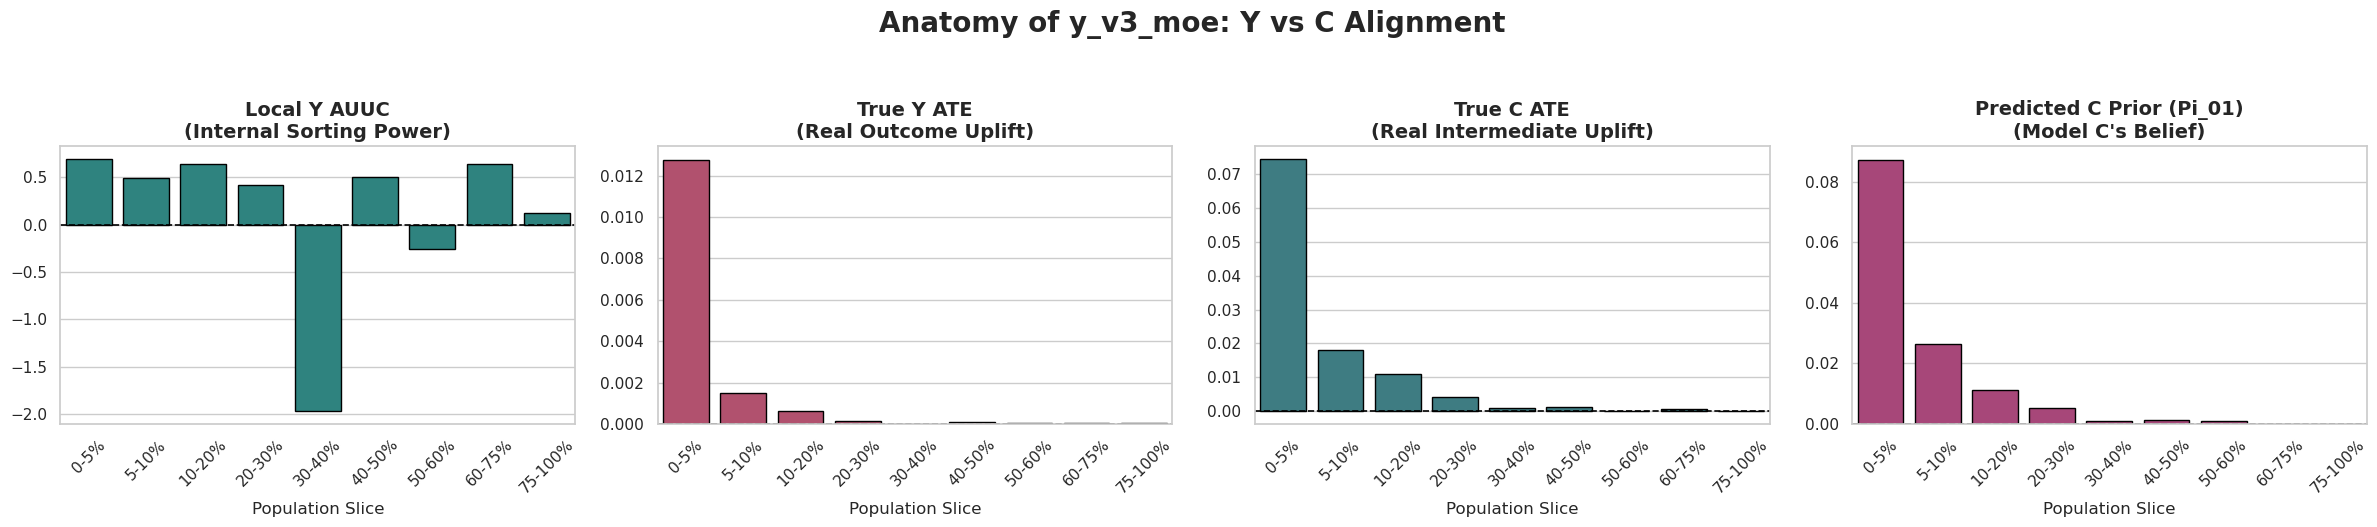

In [30]:
plot_four_dimensions(df_res, "y_v3_moe")

✅ 生成 y_v6_res_moe 剖视图: four_dim_anatomy_y_v6_res_moe.png


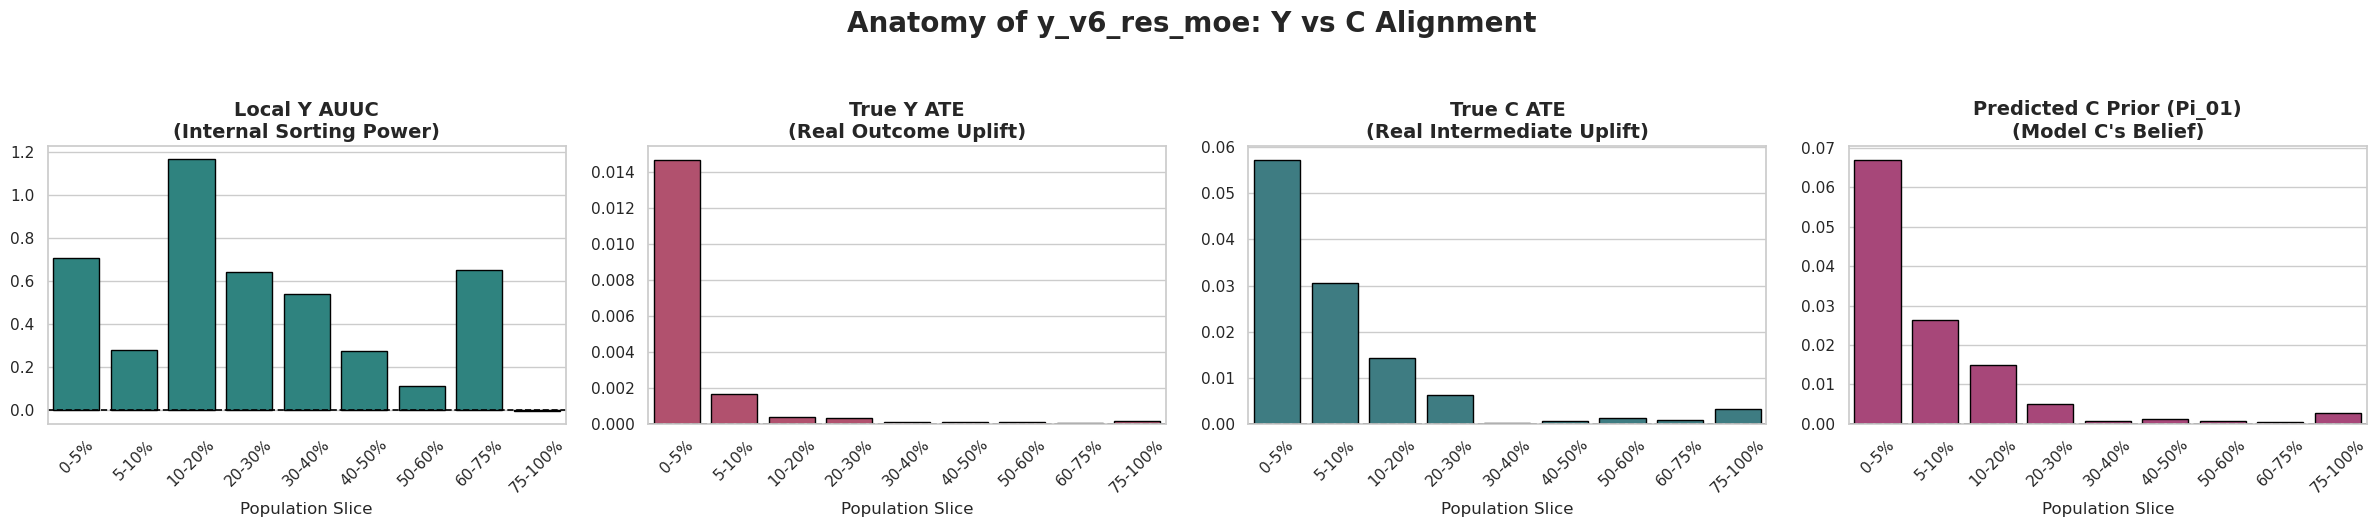

In [31]:
plot_four_dimensions(df_res, "y_v6_res_moe")